In [ ]:
# COSMIC analysis v8 - four filter comparison
# Runs all analyses from v7 under four variant-filtering conditions:
#   1. No filter
#   2. vep_most_severe != 0 (has any VEP annotation)
#   3. vep_coding_related == 0 (non-coding only)
#   4. vep_coding_related == 0 OR vep_most_severe == 'synonymous_variant'
# 031626

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from collections import Counter
pd.options.mode.chained_assignment = None

In [2]:
def oddsR_calculator(df, column_of_interest, emvar_col):
    pos = df[column_of_interest] == 1
    a = df.loc[pos, emvar_col].sum()
    b = pos.sum() - a
    c = df.loc[~pos, emvar_col].sum()
    d = (~pos).sum() - c
    table = np.array([[a, b], [c, d]])
    oddsr, pval = stats.fisher_exact(table)
    ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)
    odds_df = pd.DataFrame([{
        'label': column_of_interest,
        'OddsR': oddsr,
        'p_val': pval,
        'round_p': np.round(pval, 4),
        'lowerCI': ci[0],
        'upperCI': ci[1],
        'n_pos_emvar': a,
        'n_pos_total': int(pos.sum()),
        'n_neg_emvar': c,
        'n_neg_total': int((~pos).sum()),
    }])
    return odds_df, table

In [3]:
def oddsR_feature_by_skew_bin_all(preds_df, list_of_bins, feature, feature_ann):
    df = preds_df.copy()
    df['mean_skew_bin'] = pd.cut(df['mean_skew'], list_of_bins)
    total_with_feature = df[feature].sum()
    total_without_feature = len(df) - total_with_feature
    results = []
    for bin_label, bin_df in df.groupby('mean_skew_bin', observed=True):
        a = bin_df[feature].sum()
        b = len(bin_df) - a
        c = total_with_feature - a
        d = total_without_feature - b
        table = np.array([[a, b], [c, d]])
        oddsr, pval = stats.fisher_exact(table)
        ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)
        results.append({
            'Feature': feature_ann,
            'OddsR': oddsr,
            'p_val': pval,
            'round_p': np.round(pval, 4),
            'lowerCI': ci[0],
            'upperCI': ci[1],
            'Bin': bin_label,
            'n_bin': len(bin_df),
            'n_feature_in_bin': a,
        })
    return pd.DataFrame(results).sort_values('Bin').reset_index(drop=True)

In [4]:
def oddsR_emvar_by_act_bin_max(preds_df, skew_threshold=0.5):
    df = preds_df.copy()
    df['is_emvar'] = (df['max_skew'].abs() > skew_threshold).astype(int)
    recurrent = df[df['recurrent'] == 1]
    unique = df[df['recurrent'] != 1]
    total_recurrent = len(recurrent)
    total_unique = len(unique)
    results = []
    for bin_label in df['max_act_bin'].dropna().unique():
        bin_r = recurrent[recurrent['max_act_bin'] == bin_label]
        bin_u = unique[unique['max_act_bin'] == bin_label]
        a = bin_r['is_emvar'].sum()
        c = total_recurrent - a
        b = bin_u['is_emvar'].sum()
        d = total_unique - b
        table = np.array([[a, b], [c, d]])
        oddsr, pval = stats.fisher_exact(table)
        ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)
        results.append({
            'feature': 'emVar',
            'oddsR': oddsr,
            'p_val': pval,
            'lowerCI': ci[0],
            'upperCI': ci[1],
            'Bin': bin_label,
            'label': str(bin_label),
            'n_recurrent_emvars': a,
            'n_unique_emvars': b,
            'n_recurrent_in_bin': len(bin_r),
            'n_unique_in_bin': len(bin_u),
        })
    return pd.DataFrame(results).sort_values('Bin').reset_index(drop=True)

In [5]:
def reformat_df4act_bin(df):
    max_skew_cell = []
    max_skew_l2fc = []
    for k_skew, h_skew, s_skew in zip(df['k562_skew_pred'],
                                      df['hepg2_skew_pred'],
                                      df['sknsh_skew_pred']):
        skew_list = [k_skew, h_skew, s_skew]
        max_skew = max([k_skew, h_skew, s_skew], key=abs)
        if skew_list[0] == max_skew:
            max_skew_cell.append('k562')
            max_skew_l2fc.append(max_skew)
        elif skew_list[1] == max_skew:
            max_skew_cell.append('hepg2')
            max_skew_l2fc.append(max_skew)
        elif skew_list[2] == max_skew:
            max_skew_cell.append('sknsh')
            max_skew_l2fc.append(max_skew)
    df['max_skew_cell'] = max_skew_cell
    k_act_bin = df['k562_act_bin'].tolist()
    h_act_bin = df['hepg2_act_bin'].tolist()
    s_act_bin = df['sknsh_act_bin'].tolist()
    act_bin = []
    for i, j in tqdm(zip(range(len(df)), df['max_skew_cell'])):
        if j == 'k562':
            act_bin.append(k_act_bin[i])
        elif j == 'hepg2':
            act_bin.append(h_act_bin[i])
        elif j == 'sknsh':
            act_bin.append(s_act_bin[i])
    df['max_act_bin'] = act_bin
    df['max_skew'] = max_skew_l2fc
    return df

In [6]:
cosmic_preds = pd.read_csv(
    '../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.031626.tsv',
    sep='\t', low_memory=False
)
cosmic_preds['mean_ref_bin'] = pd.cut(cosmic_preds['mean_ref_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds['k562_act_bin']  = pd.cut(cosmic_preds['k562_max_act'],  [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds['hepg2_act_bin'] = pd.cut(cosmic_preds['hepg2_max_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds['sknsh_act_bin'] = pd.cut(cosmic_preds['sknsh_max_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
print(f'Loaded {len(cosmic_preds):,} variants')
print(f'Columns: {list(cosmic_preds.columns)}')

Loaded 2,524,101 variants
Columns: ['chrom', 'pos', 'id', 'ref', 'alt', 'k562_ref_pred', 'k562_alt_pred', 'k562_skew_pred', 'hepg2_ref_pred', 'hepg2_alt_pred', 'hepg2_skew_pred', 'sknsh_ref_pred', 'sknsh_alt_pred', 'sknsh_skew_pred', 'k562_max_act', 'hepg2_max_act', 'sknsh_max_act', 'k562_active', 'hepg2_active', 'sknsh_active', 'k562_emvar', 'hepg2_emvar', 'sknsh_emvar', 'emvar_any', 'mean_ref_act', 'mean_skew', 'max_skew', 'var_id', 'recurrence', 'recurrent', '250bp_pro', 'cnc_pro', 'dhs', 'recurrent_250bp_pro', 'recurrent_cnc_pro', 'indel', 'k562_dELS_seqlet', 'hepg2_dELS_seqlet', 'sknsh_dELS_seqlet', 'dELS_seqlet', 'encode_dELS', 'recurrent_dELS', 'k562_pro_seqlet', 'hepg2_pro_seqlet', 'sknsh_pro_seqlet', '250_pro_seqlet', 'gencode_v44_exon', 'k562_dELS_seqlet_tf_fam', 'hepg2_dELS_seqlet_tf_fam', 'sknsh_dELS_seqlet_tf_fam', 'k562_dELS_seqlet_enh_ID', 'hepg2_dELS_seqlet_enh_ID', 'sknsh_dELS_seqlet_enh_ID', 'primary_histology', 'all_histology', 'vep_most_severe', 'vep_coding_related'

In [10]:
cosmic_preds.keys()

Index(['chrom', 'pos', 'id', 'ref', 'alt', 'k562_ref_pred', 'k562_alt_pred',
       'k562_skew_pred', 'hepg2_ref_pred', 'hepg2_alt_pred', 'hepg2_skew_pred',
       'sknsh_ref_pred', 'sknsh_alt_pred', 'sknsh_skew_pred', 'k562_max_act',
       'hepg2_max_act', 'sknsh_max_act', 'k562_active', 'hepg2_active',
       'sknsh_active', 'k562_emvar', 'hepg2_emvar', 'sknsh_emvar', 'emvar_any',
       'mean_ref_act', 'mean_skew', 'max_skew', 'var_id', 'recurrence',
       'recurrent', '250bp_pro', 'cnc_pro', 'dhs', 'recurrent_250bp_pro',
       'recurrent_cnc_pro', 'indel', 'k562_dELS_seqlet', 'hepg2_dELS_seqlet',
       'sknsh_dELS_seqlet', 'dELS_seqlet', 'encode_dELS', 'recurrent_dELS',
       'k562_pro_seqlet', 'hepg2_pro_seqlet', 'sknsh_pro_seqlet',
       '250_pro_seqlet', 'gencode_v44_exon', 'k562_dELS_seqlet_tf_fam',
       'hepg2_dELS_seqlet_tf_fam', 'sknsh_dELS_seqlet_tf_fam',
       'k562_dELS_seqlet_enh_ID', 'hepg2_dELS_seqlet_enh_ID',
       'sknsh_dELS_seqlet_enh_ID', 'primary_histol

## Define four filter groups

In [11]:
# 1. No filter
noFilt = cosmic_preds.copy()

# 2. vep_most_severe is not 0 (has any VEP annotation)
vepAnn = cosmic_preds[cosmic_preds['vep_most_severe'] != 0].copy()

# 3. vep_coding_related == 0 (non-coding variants only)
nonCoding = cosmic_preds[cosmic_preds['vep_coding_related'] == 0].copy()

# 4. vep_coding_related == 0 OR vep_most_severe == 'synonymous_variant'
nonCodingSyn = cosmic_preds[
    (cosmic_preds['vep_coding_related'] == 0) |
    (cosmic_preds['vep_most_severe'] == 'synonymous_variant')
].copy()


# 5. vep_coding_related == 0 OR (vep_most_severe == 'synonymous_variant' AND dELS == 1)
nonCodingSynDELS = cosmic_preds[
    (cosmic_preds['vep_coding_related'] == 0) |
    ((cosmic_preds['vep_most_severe'] == 'synonymous_variant') & (cosmic_preds['encode_dELS'] == 1))
].copy()

filter_groups = {
    'No filter':                    noFilt,
    'vep_most_severe != 0':         vepAnn,
    'vep_coding_related == 0':      nonCoding,
    'non-coding + synonymous':      nonCodingSyn,
    'non-coding + (synonymous & dELS)': nonCodingSynDELS,
}
print('Filter group sizes:')
for name, df in filter_groups.items():
    print(f'  {name}: {len(df):,}')

Filter group sizes:
  No filter: 2,524,101
  vep_most_severe != 0: 2,524,101
  vep_coding_related == 0: 2,081,564
  non-coding + synonymous: 2,190,594
  non-coding + (synonymous & dELS): 2,111,299


## Summary: variant counts per filter group

In [12]:
# detect emvar method columns
emvar_cols = [c for c in cosmic_preds.columns
              if 'emvar' in c.lower() and cosmic_preds[c].isin([0, 1]).all()]
print('emVar columns detected:', emvar_cols)

emVar columns detected: ['k562_emvar', 'hepg2_emvar', 'sknsh_emvar', 'emvar_any']


In [13]:
summary_rows = []
for group_name, df in filter_groups.items():
    row = {
        'filter_group': group_name,
        'n_total': len(df),
        'n_recurrent': int(df['recurrent'].sum()),
    }
    for ecol in emvar_cols:
        row[f'n_{ecol}'] = int(df[ecol].sum())
        row[f'n_recurrent_{ecol}'] = int(df.loc[(df['recurrent'] == 1) & (df[ecol] == 1)].shape[0])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('filter_group')
display(summary_df)

,n_total,n_recurrent,n_k562_emvar,n_recurrent_k562_emvar,n_hepg2_emvar,n_recurrent_hepg2_emvar,n_sknsh_emvar,n_recurrent_sknsh_emvar,n_emvar_any,n_recurrent_emvar_any
filter_group,,,,,,,,,,
No filter,2524101,71793,34269,1254,26442,984,32256,1228,53176,1924
vep_most_severe != 0,2524101,71793,34269,1254,26442,984,32256,1228,53176,1924
vep_coding_related == 0,2081564,48544,25424,792,18787,586,23130,763,39042,1199
non-coding + synonymous,2190594,54307,27666,917,20820,704,25417,886,42615,1392
non-coding + (synonymous & dELS),2111299,49952,26288,841,19596,634,24018,809,40402,1269


## Analysis: No filter

In [14]:
# --- Overall odds-ratios: No filter ---
recurrent_OR_noFilt, _ = oddsR_calculator(noFilt, 'recurrent', 'emvar_any')
twoFifty_OR_noFilt, _ = oddsR_calculator(noFilt, '250bp_pro', 'emvar_any')
twoFiftySeqlet_OR_noFilt, _ = oddsR_calculator(noFilt, '250_pro_seqlet', 'emvar_any')
cnc_OR_noFilt, _ = oddsR_calculator(noFilt, 'cnc_pro', 'emvar_any')
recurrent250_OR_noFilt, _ = oddsR_calculator(noFilt, 'recurrent_250bp_pro', 'emvar_any')
recurrentCNC_OR_noFilt, _ = oddsR_calculator(noFilt, 'recurrent_cnc_pro', 'emvar_any')

cat_odds_noFilt = pd.concat([
    recurrent_OR_noFilt,
    twoFifty_OR_noFilt,
    twoFiftySeqlet_OR_noFilt,
    cnc_OR_noFilt,
    recurrent250_OR_noFilt,
    recurrentCNC_OR_noFilt,
])
cat_odds_noFilt['plot_labs'] = [
    'Recurrent', '250bp Promoter', '250bp Promoter Seqlet',
    'CNC Promoter', 'Recurrent Promoter', 'Recurrent CNC Promoter'
]
display(cat_odds_noFilt[['plot_labs','OddsR','lowerCI','upperCI','p_val','n_pos_emvar','n_pos_total']].reset_index(drop=True))

,plot_labs,OddsR,lowerCI,upperCI,p_val,n_pos_emvar,n_pos_total
0,Recurrent,1.290066,1.231273,1.351029,1.639116e-25,1924,71793
1,250bp Promoter,6.078439,5.599933,6.589535,1.473301e-273,677,5908
2,250bp Promoter Seqlet,90.201983,69.733971,117.333457,3.691298e-226,178,270
3,CNC Promoter,9.404578,6.905429,12.606997,2.667253e-32,55,327
4,Recurrent Promoter,14.533627,11.658308,18.002387,1.045377e-81,113,475
5,Recurrent CNC Promoter,16.515863,10.230977,25.928771,5.515636e-22,27,103


In [15]:
# --- OR by skew bin: No filter ---
_bins = [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')]

rec_skew_noFilt = oddsR_feature_by_skew_bin_all(noFilt, _bins, 'recurrent', 'Recurrent')
rec_skew_noFilt['label'] = [str(i) for i in rec_skew_noFilt['Bin']]

rec_skew_noPro_noFilt = oddsR_feature_by_skew_bin_all(
    noFilt[noFilt['250bp_pro'] == 0], _bins, 'recurrent', 'Recurrent: Non-Promoter')
rec_skew_noPro_noFilt['label'] = [str(i) for i in rec_skew_noPro_noFilt['Bin']]

rec_skew_noPro_dhs_noFilt = oddsR_feature_by_skew_bin_all(
    noFilt[(noFilt['250bp_pro'] == 0) & (noFilt['dhs'] == 1)], _bins, 'recurrent', 'Recurrent: In DHS')
rec_skew_noPro_dhs_noFilt['label'] = [str(i) for i in rec_skew_noPro_dhs_noFilt['Bin']]

pro_skew_noFilt = oddsR_feature_by_skew_bin_all(noFilt, _bins, '250bp_pro', '250bp Promoter')
pro_skew_noFilt['label'] = [str(i) for i in pro_skew_noFilt['Bin']]

cnc_skew_noFilt = oddsR_feature_by_skew_bin_all(noFilt, _bins, 'cnc_pro', 'CNC Promoter')
cnc_skew_noFilt['label'] = [str(i) for i in cnc_skew_noFilt['Bin']]

rec250_skew_noFilt = oddsR_feature_by_skew_bin_all(noFilt, _bins, 'recurrent_250bp_pro', 'Recurrent Promoter')
rec250_skew_noFilt['label'] = [str(i) for i in rec250_skew_noFilt['Bin']]

recCNC_skew_noFilt = oddsR_feature_by_skew_bin_all(noFilt, _bins, 'recurrent_cnc_pro', 'Recurrent CNC Promoter')
recCNC_skew_noFilt['label'] = [str(i) for i in recCNC_skew_noFilt['Bin']]

In [16]:
# --- Activity bin analysis: No filter ---
_act_noFilt = reformat_df4act_bin(noFilt)

rec_emvar_act_noFilt = oddsR_emvar_by_act_bin_max(_act_noFilt)
rec_emvar_act_noPro_noFilt = oddsR_emvar_by_act_bin_max(_act_noFilt[_act_noFilt['250bp_pro'] == 0])
rec_emvar_act_noPro_dhs_noFilt = oddsR_emvar_by_act_bin_max(
    _act_noFilt[(_act_noFilt['250bp_pro'] == 0) & (_act_noFilt['dhs'] == 1)])
rec_emvar_act_pro_noFilt = oddsR_emvar_by_act_bin_max(_act_noFilt[_act_noFilt['250bp_pro'] == 1])

2524101it [00:01, 2068735.48it/s]


/tmp/ipykernel_3808401/872370259.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',


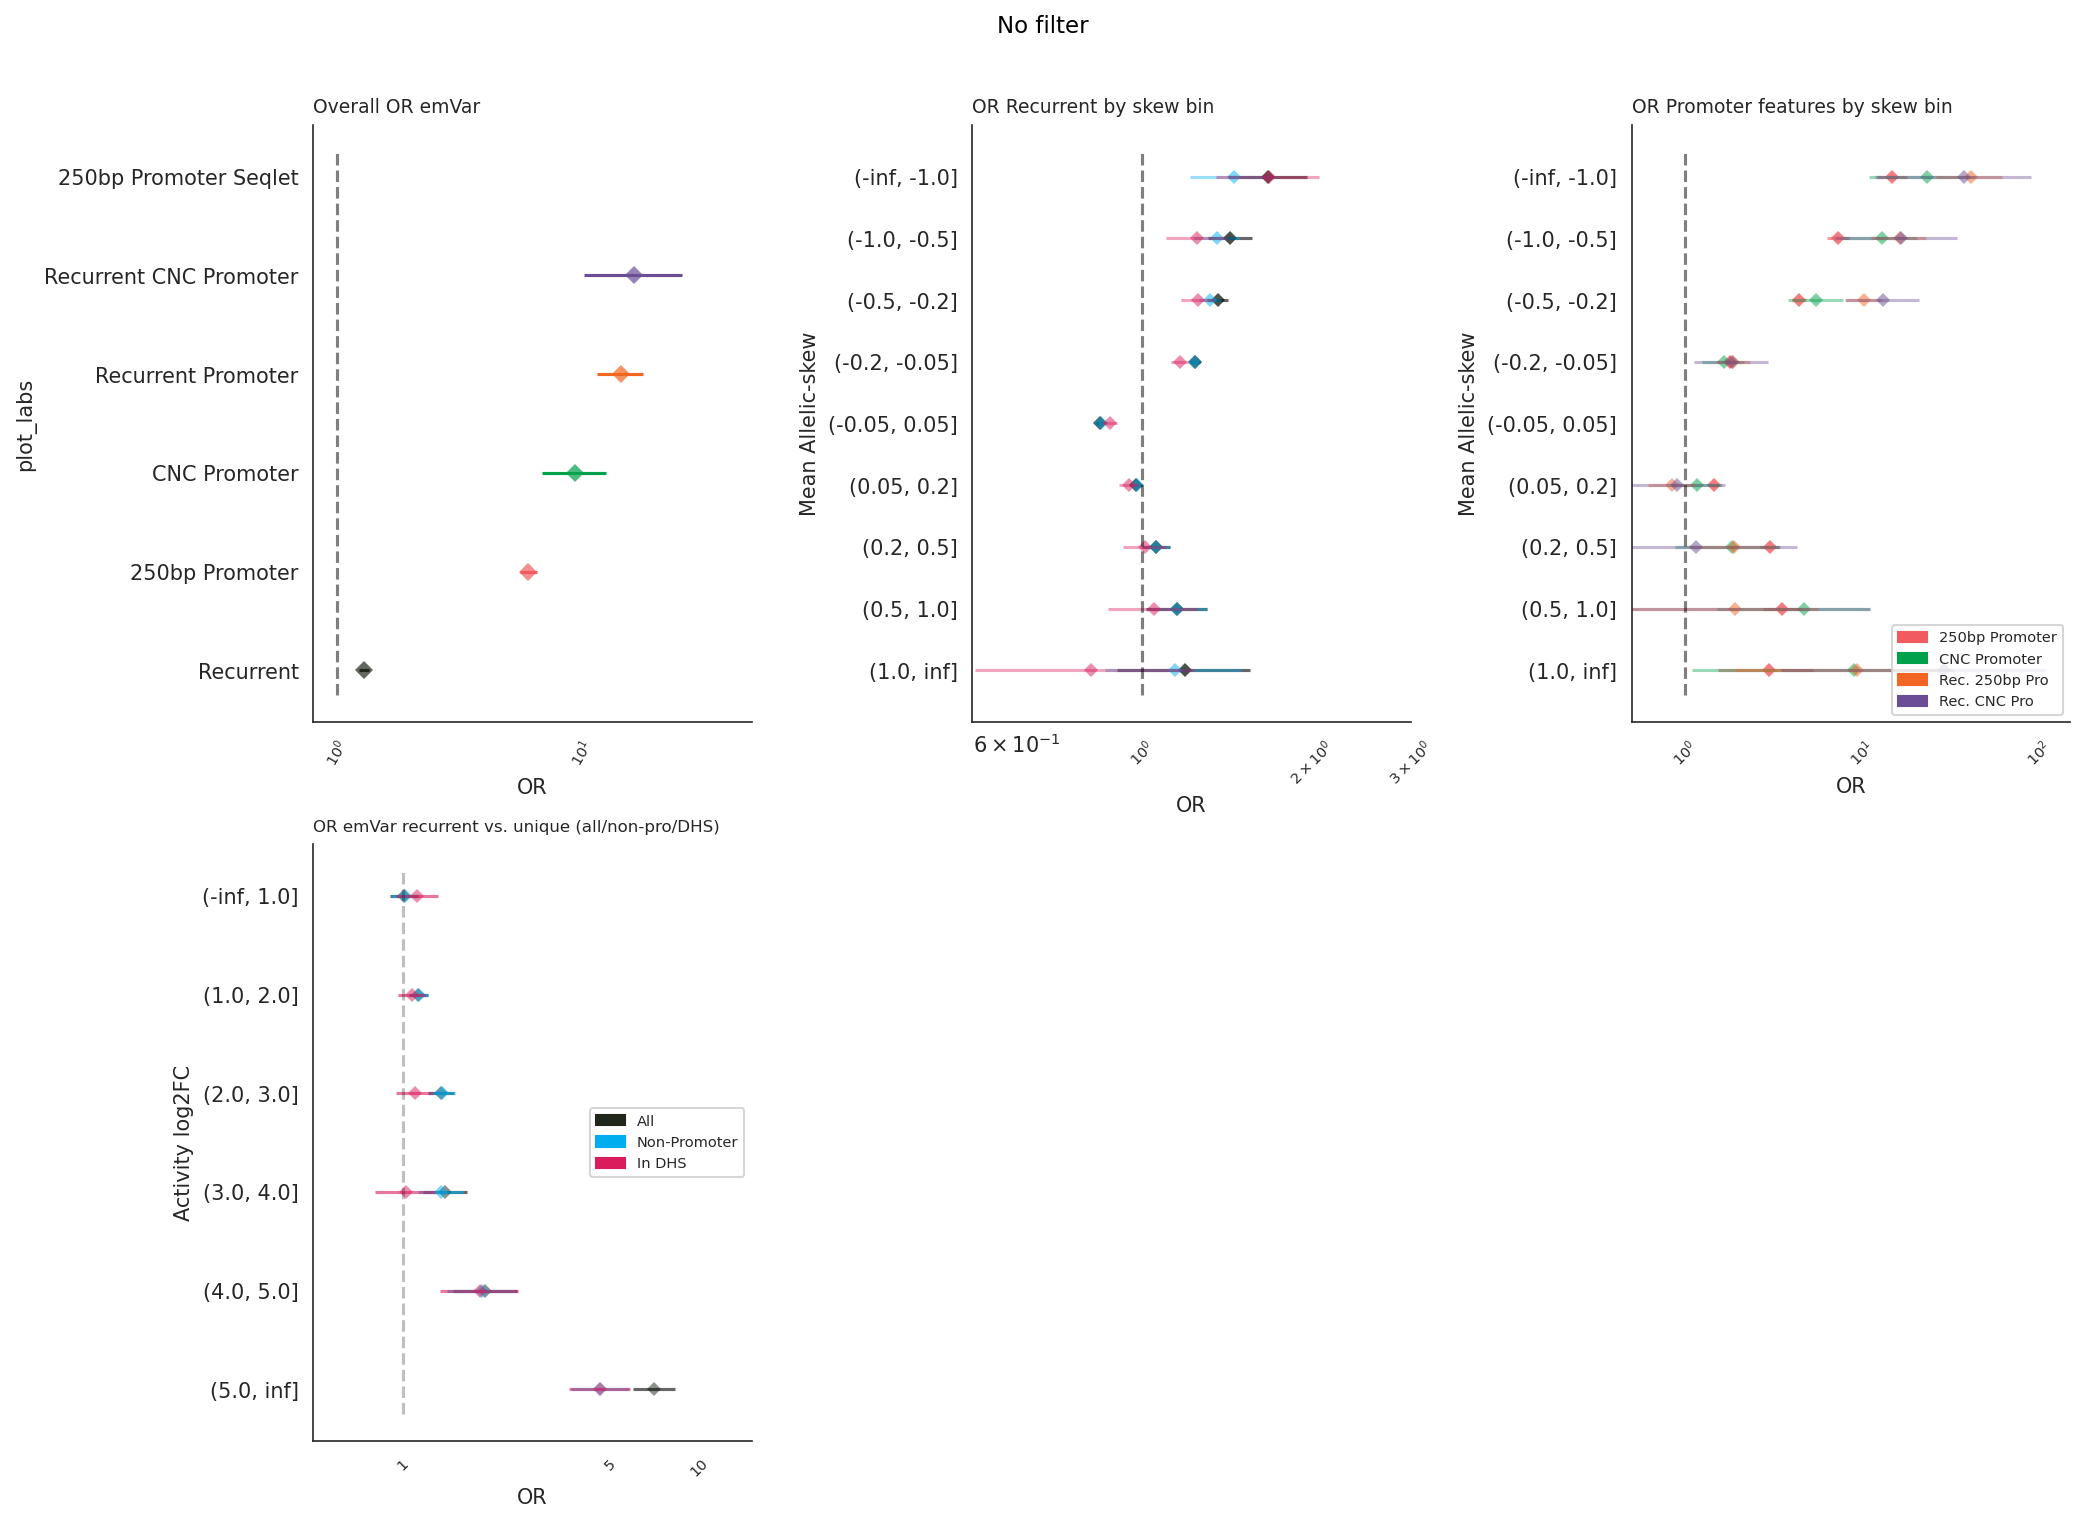

In [17]:
# --- Plot: No filter ---
feature_palette = {
    'Recurrent': '#1F271B',
    '250bp Promoter': '#F15B60',
    '250bp Promoter Seqlet': 'dodgerblue',
    'CNC Promoter': '#00A14B',
    'Recurrent Promoter': '#F26522',
    'Recurrent CNC Promoter': '#6A4D94',
}
black_patch = mpatches.Patch(color='#1F271B', label='All')
green_patch = mpatches.Patch(color='#00AEEF', label='Non-Promoter')
blue_patch  = mpatches.Patch(color='#DA1C5C', label='In DHS')

f = plt.figure(dpi=150, figsize=(14, 10))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(2, 3)

# overall OR
with sns.axes_style('white'):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    _sorted = cat_odds_noFilt.sort_values('OddsR', ascending=False)
    sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',
                  palette=feature_palette, linestyle='none', marker='D',
                  markersize=6, alpha=.7, linewidth=0)
    for _, row in _sorted.iterrows():
        plt.hlines(xmin=row['lowerCI'], xmax=row['upperCI'], y=row['plot_labs'],
                   color=feature_palette.get(row['plot_labs'], 'grey'))
    ymin, ymax = ax0.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('Overall OR emVar', loc='left', size=9)
    plt.xlabel('OR')
    plt.xticks([1, 5, 10, 20, 30], rotation=60, size=7)
    plt.xlim(.8, 50)

# skew bin - recurrent
with sns.axes_style('white'):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    sns.pointplot(data=rec_skew_noFilt, x='OddsR', y='label',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in rec_skew_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_skew_noPro_noFilt, x='OddsR', y='label',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.4)
    sns.pointplot(data=rec_skew_noPro_dhs_noFilt, x='OddsR', y='label',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_dhs_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.4)
    ymin, ymax = ax1.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Recurrent by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xlim(.5, 3)
    plt.xticks([1, 2, 3], rotation=45, size=7)
    plt.xlabel('OR')

# skew bin - promoter features
with sns.axes_style('white'):
    ax2 = f.add_subplot(gs[0, 2])
    ax2.set_xscale('log')
    sns.pointplot(data=pro_skew_noFilt, x='OddsR', y='label',
                  color='#F15B60', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in pro_skew_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F15B60', alpha=.6)
    sns.pointplot(data=cnc_skew_noFilt, x='OddsR', y='label',
                  color='#00A14B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in cnc_skew_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00A14B', alpha=.4)
    sns.pointplot(data=rec250_skew_noFilt, x='OddsR', y='label',
                  color='#F26522', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec250_skew_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F26522', alpha=.4)
    sns.pointplot(data=recCNC_skew_noFilt, x='OddsR', y='label',
                  color='#6A4D94', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in recCNC_skew_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#6A4D94', alpha=.4)
    ymin, ymax = ax2.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Promoter features by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xticks([1, 5, 10, 25, 50, 100], rotation=45, size=7)
    plt.xlim(.5, 150)
    plt.xlabel('OR')
    pro_patches = [
        mpatches.Patch(color='#F15B60', label='250bp Promoter'),
        mpatches.Patch(color='#00A14B', label='CNC Promoter'),
        mpatches.Patch(color='#F26522', label='Rec. 250bp Pro'),
        mpatches.Patch(color='#6A4D94', label='Rec. CNC Pro'),
    ]
    plt.legend(handles=pro_patches, fontsize=7, loc='lower right')

# activity bin - all/non-promoter/dhs
with sns.axes_style('white'):
    ax3 = f.add_subplot(gs[1, 0])
    ax3.set_xscale('log')
    sns.pointplot(data=rec_emvar_act_noFilt, x='oddsR', y='Bin',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_noFilt, x='oddsR', y='Bin',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_dhs_noFilt, x='oddsR', y='Bin',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_dhs_noFilt.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.6)
    ymin, ymax = ax3.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    plt.title('OR emVar recurrent vs. unique (all/non-pro/DHS)', loc='left', size=8)
    plt.xlabel('OR')
    plt.xlim(.8, 15)
    plt.xticks([0.5, 1, 5, 10], ['', '1', '5', '10'], rotation=45, size=7)
    plt.ylabel('Activity log2FC')
    plt.legend(handles=[black_patch, green_patch, blue_patch], fontsize=7, loc='center right')

sns.despine()
plt.suptitle('No filter', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# --- Recurrent OR by skew bin: No filter ---
print('--- OR recurrent by skew bin (all): No filter ---')
display(rec_skew_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (non-promoter): No filter ---')
display(rec_skew_noPro_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (in DHS): No filter ---')
display(rec_skew_noPro_dhs_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Promoter features OR by skew bin: No filter ---
print('--- OR 250bp promoter by skew bin: No filter ---')
display(pro_skew_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR CNC promoter by skew bin: No filter ---')
display(cnc_skew_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent 250bp promoter by skew bin: No filter ---')
display(rec250_skew_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent CNC promoter by skew bin: No filter ---')
display(recCNC_skew_noFilt[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Activity bin tables: No filter ---
print('--- Activity bin OR table (all): No filter ---')
display(rec_emvar_act_noFilt[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter): No filter ---')
display(rec_emvar_act_noPro_noFilt[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (dhs): No filter ---')
display(rec_emvar_act_noPro_dhs_noFilt[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])

--- OR recurrent by skew bin (all): No filter ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.673866,1.418964,1.962572,3.679507e-09,160,3428
1,"(-1.0, -0.5]",1.435485,1.310692,1.569248,4.213043e-14,509,12647
2,"(-0.5, -0.2]",1.361299,1.302571,1.422081,4.049259e-40,2161,56822
3,"(-0.2, -0.05]",1.241362,1.216818,1.266323,2.330091e-96,12073,355510
4,"(-0.05, 0.05]",0.840463,0.827408,0.853740,1.937526e-103,47074,1748488
5,"(0.05, 0.2]",0.975974,0.953367,0.999018,4.077586e-02,8208,294673
6,"(0.2, 0.5]",1.060518,1.001837,1.121822,4.085933e-02,1279,42516
7,"(0.5, 1.0]",1.153504,1.017977,1.302403,2.246809e-02,271,8300
8,"(1.0, inf]",1.194350,0.902781,1.552021,1.903790e-01,58,1717


--- OR recurrent by skew bin (non-promoter): No filter ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.457395,1.217405,1.731979,5.172991e-05,135,3315
1,"(-1.0, -0.5]",1.358467,1.236225,1.489810,4.345895e-10,473,12440
2,"(-0.5, -0.2]",1.319317,1.261244,1.379461,9.819189e-32,2070,56282
3,"(-0.2, -0.05]",1.239339,1.214731,1.264369,3.567533e-94,11961,354168
4,"(-0.05, 0.05]",0.846870,0.833652,0.860315,6.502752e-94,46932,1746108
5,"(0.05, 0.2]",0.977889,0.955171,1.001047,6.150106e-02,8160,293716
6,"(0.2, 0.5]",1.059747,1.000774,1.121371,4.580860e-02,1264,42227
7,"(0.5, 1.0]",1.155142,1.018697,1.305128,2.166412e-02,268,8232
8,"(1.0, inf]",1.143756,0.857782,1.496382,3.069440e-01,55,1705


--- OR recurrent by skew bin (in DHS): No filter ---


...

,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.012958,0.910073,1.124498,8.094701e-01,365,12309,60881,2178438
1,"(1.0, 2.0]",1.130588,1.050405,1.215403,1.044536e-03,768,23232,7706,207101
2,"(2.0, 3.0]",1.349444,1.216620,1.493144,2.446975e-08,393,9962,1816,43820
3,"(3.0, 4.0]",1.391725,1.171814,1.641859,1.824299e-04,147,3610,582,13797
4,"(4.0, 5.0]",1.901565,1.472676,2.420285,1.923069e-06,70,1258,291,5344
5,"(5.0, inf]",7.032922,5.958837,8.263314,1.651895e-82,181,881,517,3808


--- Activity bin OR table (non-promoter): No filter ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.018383,0.914944,1.130524,7.269885e-01,365,12298,60831,2177124
1,"(1.0, 2.0]",1.132382,1.051869,1.217558,9.368689e-04,764,23177,7668,206204
2,"(2.0, 3.0]",1.359486,1.225333,1.504653,1.405024e-08,391,9882,1793,43078
3,"(3.0, 4.0]",1.349977,1.130276,1.600860,9.526797e-04,138,3509,545,13061
4,"(4.0, 5.0]",1.853687,1.411644,2.394589,1.218985e-05,62,1148,223,4664
5,"(5.0, inf]",4.636913,3.682999,5.779609,4.800991e-30,91,674,258,2744


--- Activity bin OR table (dhs): No filter ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.120742,0.950046,1.313971,1.586541e-01,159,4352,15284,497112
1,"(1.0, 2.0]",1.073304,0.966682,1.188794,1.788692e-01,389,11123,3728,99798
2,"(2.0, 3.0]",1.096958,0.948958,1.262047,1.921385e-01,205,5733,1029,25514
3,"(3.0, 4.0]",1.024884,0.805486,1.286857,8.142621e-01,77,2303,328,8394
4,"(4.0, 5.0]",1.827258,1.335674,2.446926,1.716854e-04,48,806,168,3368
5,"(5.0, inf]",4.628748,3.633536,5.833727,1.240160e-27,84,558,227,2243


## Analysis: vep_most_severe != 0

In [19]:
# --- Overall odds-ratios: vep_most_severe != 0 ---
recurrent_OR_vepAnn, _ = oddsR_calculator(vepAnn, 'recurrent', 'emvar_any')
twoFifty_OR_vepAnn, _ = oddsR_calculator(vepAnn, '250bp_pro', 'emvar_any')
twoFiftySeqlet_OR_vepAnn, _ = oddsR_calculator(vepAnn, '250_pro_seqlet', 'emvar_any')
cnc_OR_vepAnn, _ = oddsR_calculator(vepAnn, 'cnc_pro', 'emvar_any')
recurrent250_OR_vepAnn, _ = oddsR_calculator(vepAnn, 'recurrent_250bp_pro', 'emvar_any')
recurrentCNC_OR_vepAnn, _ = oddsR_calculator(vepAnn, 'recurrent_cnc_pro', 'emvar_any')

cat_odds_vepAnn = pd.concat([
    recurrent_OR_vepAnn,
    twoFifty_OR_vepAnn,
    twoFiftySeqlet_OR_vepAnn,
    cnc_OR_vepAnn,
    recurrent250_OR_vepAnn,
    recurrentCNC_OR_vepAnn,
])
cat_odds_vepAnn['plot_labs'] = [
    'Recurrent', '250bp Promoter', '250bp Promoter Seqlet',
    'CNC Promoter', 'Recurrent Promoter', 'Recurrent CNC Promoter'
]
display(cat_odds_vepAnn[['plot_labs','OddsR','lowerCI','upperCI','p_val','n_pos_emvar','n_pos_total']].reset_index(drop=True))

,plot_labs,OddsR,lowerCI,upperCI,p_val,n_pos_emvar,n_pos_total
0,Recurrent,1.290066,1.231273,1.351029,1.639116e-25,1924,71793
1,250bp Promoter,6.078439,5.599933,6.589535,1.473301e-273,677,5908
2,250bp Promoter Seqlet,90.201983,69.733971,117.333457,3.691298e-226,178,270
3,CNC Promoter,9.404578,6.905429,12.606997,2.667253e-32,55,327
4,Recurrent Promoter,14.533627,11.658308,18.002387,1.045377e-81,113,475
5,Recurrent CNC Promoter,16.515863,10.230977,25.928771,5.515636e-22,27,103


In [20]:
# --- OR by skew bin: vep_most_severe != 0 ---
_bins = [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')]

rec_skew_vepAnn = oddsR_feature_by_skew_bin_all(vepAnn, _bins, 'recurrent', 'Recurrent')
rec_skew_vepAnn['label'] = [str(i) for i in rec_skew_vepAnn['Bin']]

rec_skew_noPro_vepAnn = oddsR_feature_by_skew_bin_all(
    vepAnn[vepAnn['250bp_pro'] == 0], _bins, 'recurrent', 'Recurrent: Non-Promoter')
rec_skew_noPro_vepAnn['label'] = [str(i) for i in rec_skew_noPro_vepAnn['Bin']]

rec_skew_noPro_dhs_vepAnn = oddsR_feature_by_skew_bin_all(
    vepAnn[(vepAnn['250bp_pro'] == 0) & (vepAnn['dhs'] == 1)], _bins, 'recurrent', 'Recurrent: In DHS')
rec_skew_noPro_dhs_vepAnn['label'] = [str(i) for i in rec_skew_noPro_dhs_vepAnn['Bin']]

pro_skew_vepAnn = oddsR_feature_by_skew_bin_all(vepAnn, _bins, '250bp_pro', '250bp Promoter')
pro_skew_vepAnn['label'] = [str(i) for i in pro_skew_vepAnn['Bin']]

cnc_skew_vepAnn = oddsR_feature_by_skew_bin_all(vepAnn, _bins, 'cnc_pro', 'CNC Promoter')
cnc_skew_vepAnn['label'] = [str(i) for i in cnc_skew_vepAnn['Bin']]

rec250_skew_vepAnn = oddsR_feature_by_skew_bin_all(vepAnn, _bins, 'recurrent_250bp_pro', 'Recurrent Promoter')
rec250_skew_vepAnn['label'] = [str(i) for i in rec250_skew_vepAnn['Bin']]

recCNC_skew_vepAnn = oddsR_feature_by_skew_bin_all(vepAnn, _bins, 'recurrent_cnc_pro', 'Recurrent CNC Promoter')
recCNC_skew_vepAnn['label'] = [str(i) for i in recCNC_skew_vepAnn['Bin']]

In [21]:
# --- Activity bin analysis: vep_most_severe != 0 ---
_act_vepAnn = reformat_df4act_bin(vepAnn)

rec_emvar_act_vepAnn = oddsR_emvar_by_act_bin_max(_act_vepAnn)
rec_emvar_act_noPro_vepAnn = oddsR_emvar_by_act_bin_max(_act_vepAnn[_act_vepAnn['250bp_pro'] == 0])
rec_emvar_act_noPro_dhs_vepAnn = oddsR_emvar_by_act_bin_max(
    _act_vepAnn[(_act_vepAnn['250bp_pro'] == 0) & (_act_vepAnn['dhs'] == 1)])
rec_emvar_act_pro_vepAnn = oddsR_emvar_by_act_bin_max(_act_vepAnn[_act_vepAnn['250bp_pro'] == 1])

2524101it [00:01, 2067794.02it/s]


/tmp/ipykernel_3808401/643857675.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',


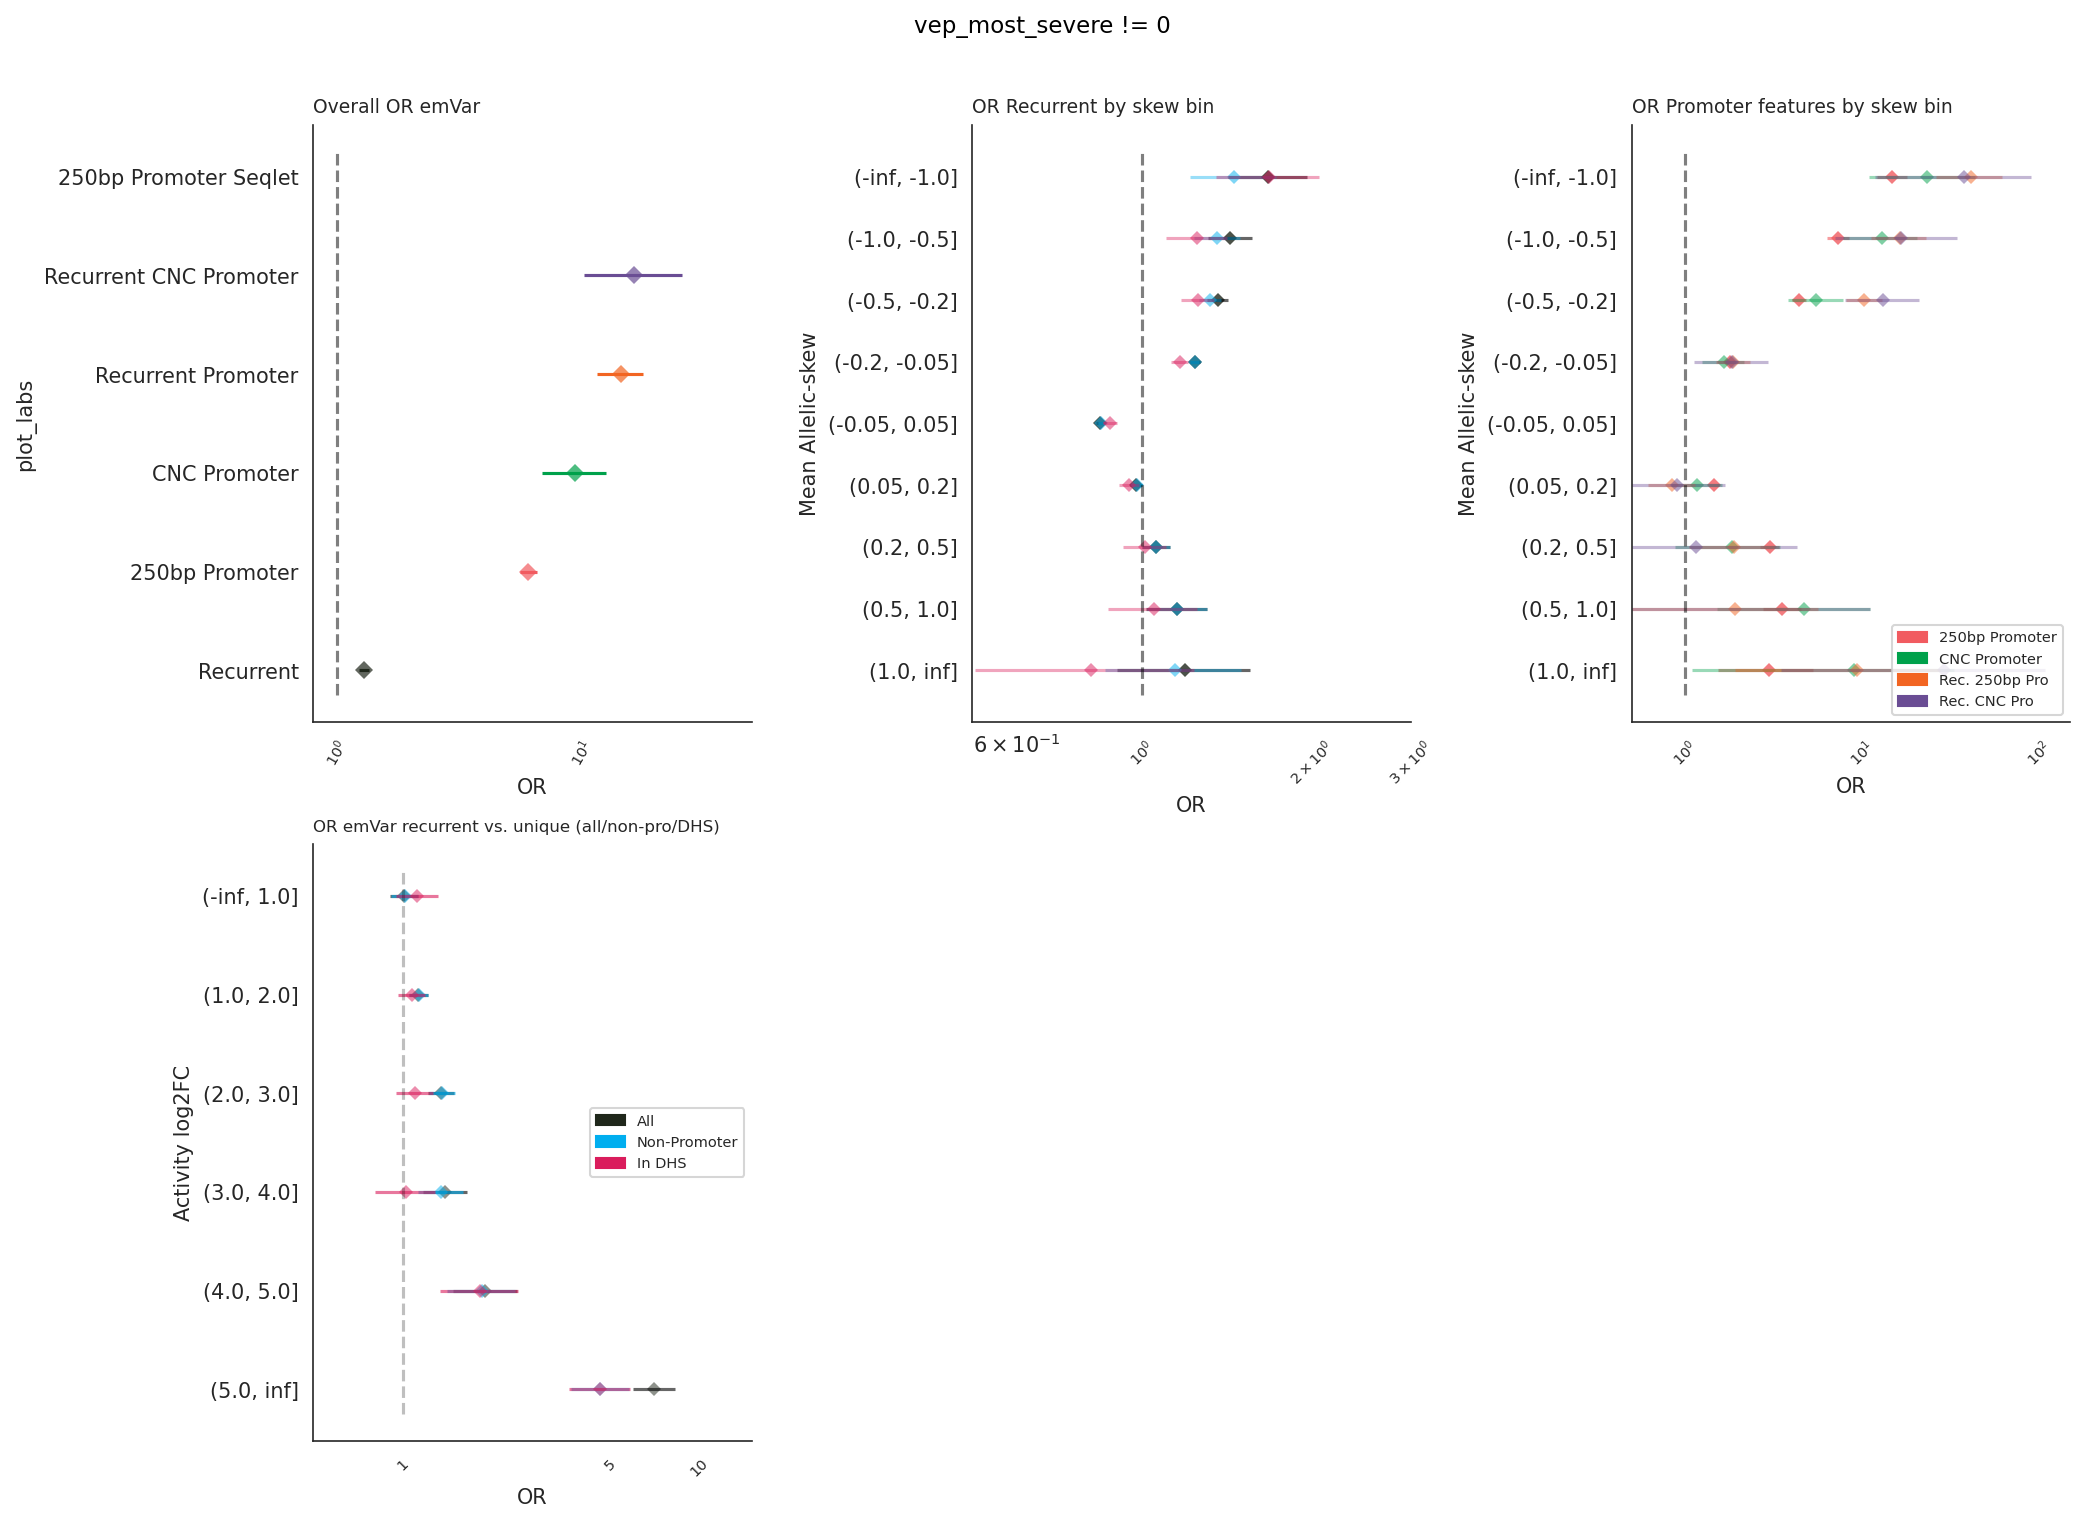

In [22]:
# --- Plot: vep_most_severe != 0 ---
feature_palette = {
    'Recurrent': '#1F271B',
    '250bp Promoter': '#F15B60',
    '250bp Promoter Seqlet': 'dodgerblue',
    'CNC Promoter': '#00A14B',
    'Recurrent Promoter': '#F26522',
    'Recurrent CNC Promoter': '#6A4D94',
}
black_patch = mpatches.Patch(color='#1F271B', label='All')
green_patch = mpatches.Patch(color='#00AEEF', label='Non-Promoter')
blue_patch  = mpatches.Patch(color='#DA1C5C', label='In DHS')

f = plt.figure(dpi=150, figsize=(14, 10))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(2, 3)

# overall OR
with sns.axes_style('white'):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    _sorted = cat_odds_vepAnn.sort_values('OddsR', ascending=False)
    sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',
                  palette=feature_palette, linestyle='none', marker='D',
                  markersize=6, alpha=.7, linewidth=0)
    for _, row in _sorted.iterrows():
        plt.hlines(xmin=row['lowerCI'], xmax=row['upperCI'], y=row['plot_labs'],
                   color=feature_palette.get(row['plot_labs'], 'grey'))
    ymin, ymax = ax0.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('Overall OR emVar', loc='left', size=9)
    plt.xlabel('OR')
    plt.xticks([1, 5, 10, 20, 30], rotation=60, size=7)
    plt.xlim(.8, 50)

# skew bin - recurrent
with sns.axes_style('white'):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    sns.pointplot(data=rec_skew_vepAnn, x='OddsR', y='label',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in rec_skew_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_skew_noPro_vepAnn, x='OddsR', y='label',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.4)
    sns.pointplot(data=rec_skew_noPro_dhs_vepAnn, x='OddsR', y='label',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_dhs_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.4)
    ymin, ymax = ax1.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Recurrent by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xlim(.5, 3)
    plt.xticks([1, 2, 3], rotation=45, size=7)
    plt.xlabel('OR')

# skew bin - promoter features
with sns.axes_style('white'):
    ax2 = f.add_subplot(gs[0, 2])
    ax2.set_xscale('log')
    sns.pointplot(data=pro_skew_vepAnn, x='OddsR', y='label',
                  color='#F15B60', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in pro_skew_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F15B60', alpha=.6)
    sns.pointplot(data=cnc_skew_vepAnn, x='OddsR', y='label',
                  color='#00A14B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in cnc_skew_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00A14B', alpha=.4)
    sns.pointplot(data=rec250_skew_vepAnn, x='OddsR', y='label',
                  color='#F26522', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec250_skew_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F26522', alpha=.4)
    sns.pointplot(data=recCNC_skew_vepAnn, x='OddsR', y='label',
                  color='#6A4D94', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in recCNC_skew_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#6A4D94', alpha=.4)
    ymin, ymax = ax2.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Promoter features by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xticks([1, 5, 10, 25, 50, 100], rotation=45, size=7)
    plt.xlim(.5, 150)
    plt.xlabel('OR')
    pro_patches = [
        mpatches.Patch(color='#F15B60', label='250bp Promoter'),
        mpatches.Patch(color='#00A14B', label='CNC Promoter'),
        mpatches.Patch(color='#F26522', label='Rec. 250bp Pro'),
        mpatches.Patch(color='#6A4D94', label='Rec. CNC Pro'),
    ]
    plt.legend(handles=pro_patches, fontsize=7, loc='lower right')

# activity bin - all/non-promoter/dhs
with sns.axes_style('white'):
    ax3 = f.add_subplot(gs[1, 0])
    ax3.set_xscale('log')
    sns.pointplot(data=rec_emvar_act_vepAnn, x='oddsR', y='Bin',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_vepAnn, x='oddsR', y='Bin',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_dhs_vepAnn, x='oddsR', y='Bin',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_dhs_vepAnn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.6)
    ymin, ymax = ax3.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    plt.title('OR emVar recurrent vs. unique (all/non-pro/DHS)', loc='left', size=8)
    plt.xlabel('OR')
    plt.xlim(.8, 15)
    plt.xticks([0.5, 1, 5, 10], ['', '1', '5', '10'], rotation=45, size=7)
    plt.ylabel('Activity log2FC')
    plt.legend(handles=[black_patch, green_patch, blue_patch], fontsize=7, loc='center right')

sns.despine()
plt.suptitle('vep_most_severe != 0', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# --- Recurrent OR by skew bin: vep_most_severe != 0 ---
print('--- OR recurrent by skew bin (all): vep_most_severe != 0 ---')
display(rec_skew_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (non-promoter): vep_most_severe != 0 ---')
display(rec_skew_noPro_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (in DHS): vep_most_severe != 0 ---')
display(rec_skew_noPro_dhs_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Promoter features OR by skew bin: vep_most_severe != 0 ---
print('--- OR 250bp promoter by skew bin: vep_most_severe != 0 ---')
display(pro_skew_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR CNC promoter by skew bin: vep_most_severe != 0 ---')
display(cnc_skew_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent 250bp promoter by skew bin: vep_most_severe != 0 ---')
display(rec250_skew_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent CNC promoter by skew bin: vep_most_severe != 0 ---')
display(recCNC_skew_vepAnn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Activity bin tables: vep_most_severe != 0 ---
print('--- Activity bin OR table (all): vep_most_severe != 0 ---')
display(rec_emvar_act_vepAnn[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter): vep_most_severe != 0 ---')
display(rec_emvar_act_noPro_vepAnn[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (dhs): vep_most_severe != 0 ---')
display(rec_emvar_act_noPro_dhs_vepAnn[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])

--- OR recurrent by skew bin (all): vep_most_severe != 0 ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.673866,1.418964,1.962572,3.679507e-09,160,3428
1,"(-1.0, -0.5]",1.435485,1.310692,1.569248,4.213043e-14,509,12647
2,"(-0.5, -0.2]",1.361299,1.302571,1.422081,4.049259e-40,2161,56822
3,"(-0.2, -0.05]",1.241362,1.216818,1.266323,2.330091e-96,12073,355510
4,"(-0.05, 0.05]",0.840463,0.827408,0.853740,1.937526e-103,47074,1748488
5,"(0.05, 0.2]",0.975974,0.953367,0.999018,4.077586e-02,8208,294673
6,"(0.2, 0.5]",1.060518,1.001837,1.121822,4.085933e-02,1279,42516
7,"(0.5, 1.0]",1.153504,1.017977,1.302403,2.246809e-02,271,8300
8,"(1.0, inf]",1.194350,0.902781,1.552021,1.903790e-01,58,1717


--- OR recurrent by skew bin (non-promoter): vep_most_severe != 0 ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.457395,1.217405,1.731979,5.172991e-05,135,3315
1,"(-1.0, -0.5]",1.358467,1.236225,1.489810,4.345895e-10,473,12440
2,"(-0.5, -0.2]",1.319317,1.261244,1.379461,9.819189e-32,2070,56282
3,"(-0.2, -0.05]",1.239339,1.214731,1.264369,3.567533e-94,11961,354168
4,"(-0.05, 0.05]",0.846870,0.833652,0.860315,6.502752e-94,46932,1746108
5,"(0.05, 0.2]",0.977889,0.955171,1.001047,6.150106e-02,8160,293716
6,"(0.2, 0.5]",1.059747,1.000774,1.121371,4.580860e-02,1264,42227
7,"(0.5, 1.0]",1.155142,1.018697,1.305128,2.166412e-02,268,8232
8,"(1.0, inf]",1.143756,0.857782,1.496382,3.069440e-01,55,1705


--- OR recurrent by skew bin (in DHS): vep_most_severe != 0 ---


...

,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.012958,0.910073,1.124498,8.094701e-01,365,12309,60881,2178438
1,"(1.0, 2.0]",1.130588,1.050405,1.215403,1.044536e-03,768,23232,7706,207101
2,"(2.0, 3.0]",1.349444,1.216620,1.493144,2.446975e-08,393,9962,1816,43820
3,"(3.0, 4.0]",1.391725,1.171814,1.641859,1.824299e-04,147,3610,582,13797
4,"(4.0, 5.0]",1.901565,1.472676,2.420285,1.923069e-06,70,1258,291,5344
5,"(5.0, inf]",7.032922,5.958837,8.263314,1.651895e-82,181,881,517,3808


--- Activity bin OR table (non-promoter): vep_most_severe != 0 ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.018383,0.914944,1.130524,7.269885e-01,365,12298,60831,2177124
1,"(1.0, 2.0]",1.132382,1.051869,1.217558,9.368689e-04,764,23177,7668,206204
2,"(2.0, 3.0]",1.359486,1.225333,1.504653,1.405024e-08,391,9882,1793,43078
3,"(3.0, 4.0]",1.349977,1.130276,1.600860,9.526797e-04,138,3509,545,13061
4,"(4.0, 5.0]",1.853687,1.411644,2.394589,1.218985e-05,62,1148,223,4664
5,"(5.0, inf]",4.636913,3.682999,5.779609,4.800991e-30,91,674,258,2744


--- Activity bin OR table (dhs): vep_most_severe != 0 ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.120742,0.950046,1.313971,1.586541e-01,159,4352,15284,497112
1,"(1.0, 2.0]",1.073304,0.966682,1.188794,1.788692e-01,389,11123,3728,99798
2,"(2.0, 3.0]",1.096958,0.948958,1.262047,1.921385e-01,205,5733,1029,25514
3,"(3.0, 4.0]",1.024884,0.805486,1.286857,8.142621e-01,77,2303,328,8394
4,"(4.0, 5.0]",1.827258,1.335674,2.446926,1.716854e-04,48,806,168,3368
5,"(5.0, inf]",4.628748,3.633536,5.833727,1.240160e-27,84,558,227,2243


## Analysis: vep_coding_related == 0

In [24]:
# --- Overall odds-ratios: vep_coding_related == 0 ---
recurrent_OR_nonCoding, _ = oddsR_calculator(nonCoding, 'recurrent', 'emvar_any')
twoFifty_OR_nonCoding, _ = oddsR_calculator(nonCoding, '250bp_pro', 'emvar_any')
twoFiftySeqlet_OR_nonCoding, _ = oddsR_calculator(nonCoding, '250_pro_seqlet', 'emvar_any')
cnc_OR_nonCoding, _ = oddsR_calculator(nonCoding, 'cnc_pro', 'emvar_any')
recurrent250_OR_nonCoding, _ = oddsR_calculator(nonCoding, 'recurrent_250bp_pro', 'emvar_any')
recurrentCNC_OR_nonCoding, _ = oddsR_calculator(nonCoding, 'recurrent_cnc_pro', 'emvar_any')

cat_odds_nonCoding = pd.concat([
    recurrent_OR_nonCoding,
    twoFifty_OR_nonCoding,
    twoFiftySeqlet_OR_nonCoding,
    cnc_OR_nonCoding,
    recurrent250_OR_nonCoding,
    recurrentCNC_OR_nonCoding,
])
cat_odds_nonCoding['plot_labs'] = [
    'Recurrent', '250bp Promoter', '250bp Promoter Seqlet',
    'CNC Promoter', 'Recurrent Promoter', 'Recurrent CNC Promoter'
]
display(cat_odds_nonCoding[['plot_labs','OddsR','lowerCI','upperCI','p_val','n_pos_emvar','n_pos_total']].reset_index(drop=True))

,plot_labs,OddsR,lowerCI,upperCI,p_val,n_pos_emvar,n_pos_total
0,Recurrent,1.335183,1.258641,1.415292,9.604432e-21,1199,48544
1,250bp Promoter,6.872612,6.330506,7.451786,6.321381e-303,677,5908
2,250bp Promoter Seqlet,100.362125,77.194915,131.230108,4.390849e-224,170,259
3,CNC Promoter,10.592120,7.777026,14.199630,8.309006e-35,55,327
4,Recurrent Promoter,16.375192,13.134674,20.284827,4.641886e-87,113,475
5,Recurrent CNC Promoter,18.598124,11.520481,29.198739,2.837216e-23,27,103


In [25]:
# --- OR by skew bin: vep_coding_related == 0 ---
_bins = [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')]

rec_skew_nonCoding = oddsR_feature_by_skew_bin_all(nonCoding, _bins, 'recurrent', 'Recurrent')
rec_skew_nonCoding['label'] = [str(i) for i in rec_skew_nonCoding['Bin']]

rec_skew_noPro_nonCoding = oddsR_feature_by_skew_bin_all(
    nonCoding[nonCoding['250bp_pro'] == 0], _bins, 'recurrent', 'Recurrent: Non-Promoter')
rec_skew_noPro_nonCoding['label'] = [str(i) for i in rec_skew_noPro_nonCoding['Bin']]

rec_skew_noPro_dhs_nonCoding = oddsR_feature_by_skew_bin_all(
    nonCoding[(nonCoding['250bp_pro'] == 0) & (nonCoding['dhs'] == 1)], _bins, 'recurrent', 'Recurrent: In DHS')
rec_skew_noPro_dhs_nonCoding['label'] = [str(i) for i in rec_skew_noPro_dhs_nonCoding['Bin']]

pro_skew_nonCoding = oddsR_feature_by_skew_bin_all(nonCoding, _bins, '250bp_pro', '250bp Promoter')
pro_skew_nonCoding['label'] = [str(i) for i in pro_skew_nonCoding['Bin']]

cnc_skew_nonCoding = oddsR_feature_by_skew_bin_all(nonCoding, _bins, 'cnc_pro', 'CNC Promoter')
cnc_skew_nonCoding['label'] = [str(i) for i in cnc_skew_nonCoding['Bin']]

rec250_skew_nonCoding = oddsR_feature_by_skew_bin_all(nonCoding, _bins, 'recurrent_250bp_pro', 'Recurrent Promoter')
rec250_skew_nonCoding['label'] = [str(i) for i in rec250_skew_nonCoding['Bin']]

recCNC_skew_nonCoding = oddsR_feature_by_skew_bin_all(nonCoding, _bins, 'recurrent_cnc_pro', 'Recurrent CNC Promoter')
recCNC_skew_nonCoding['label'] = [str(i) for i in recCNC_skew_nonCoding['Bin']]

In [26]:
# --- Activity bin analysis: vep_coding_related == 0 ---
_act_nonCoding = reformat_df4act_bin(nonCoding)

rec_emvar_act_nonCoding = oddsR_emvar_by_act_bin_max(_act_nonCoding)
rec_emvar_act_noPro_nonCoding = oddsR_emvar_by_act_bin_max(_act_nonCoding[_act_nonCoding['250bp_pro'] == 0])
rec_emvar_act_noPro_dhs_nonCoding = oddsR_emvar_by_act_bin_max(
    _act_nonCoding[(_act_nonCoding['250bp_pro'] == 0) & (_act_nonCoding['dhs'] == 1)])
rec_emvar_act_pro_nonCoding = oddsR_emvar_by_act_bin_max(_act_nonCoding[_act_nonCoding['250bp_pro'] == 1])

2081564it [00:01, 1981814.69it/s]


/tmp/ipykernel_3808401/195516351.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',


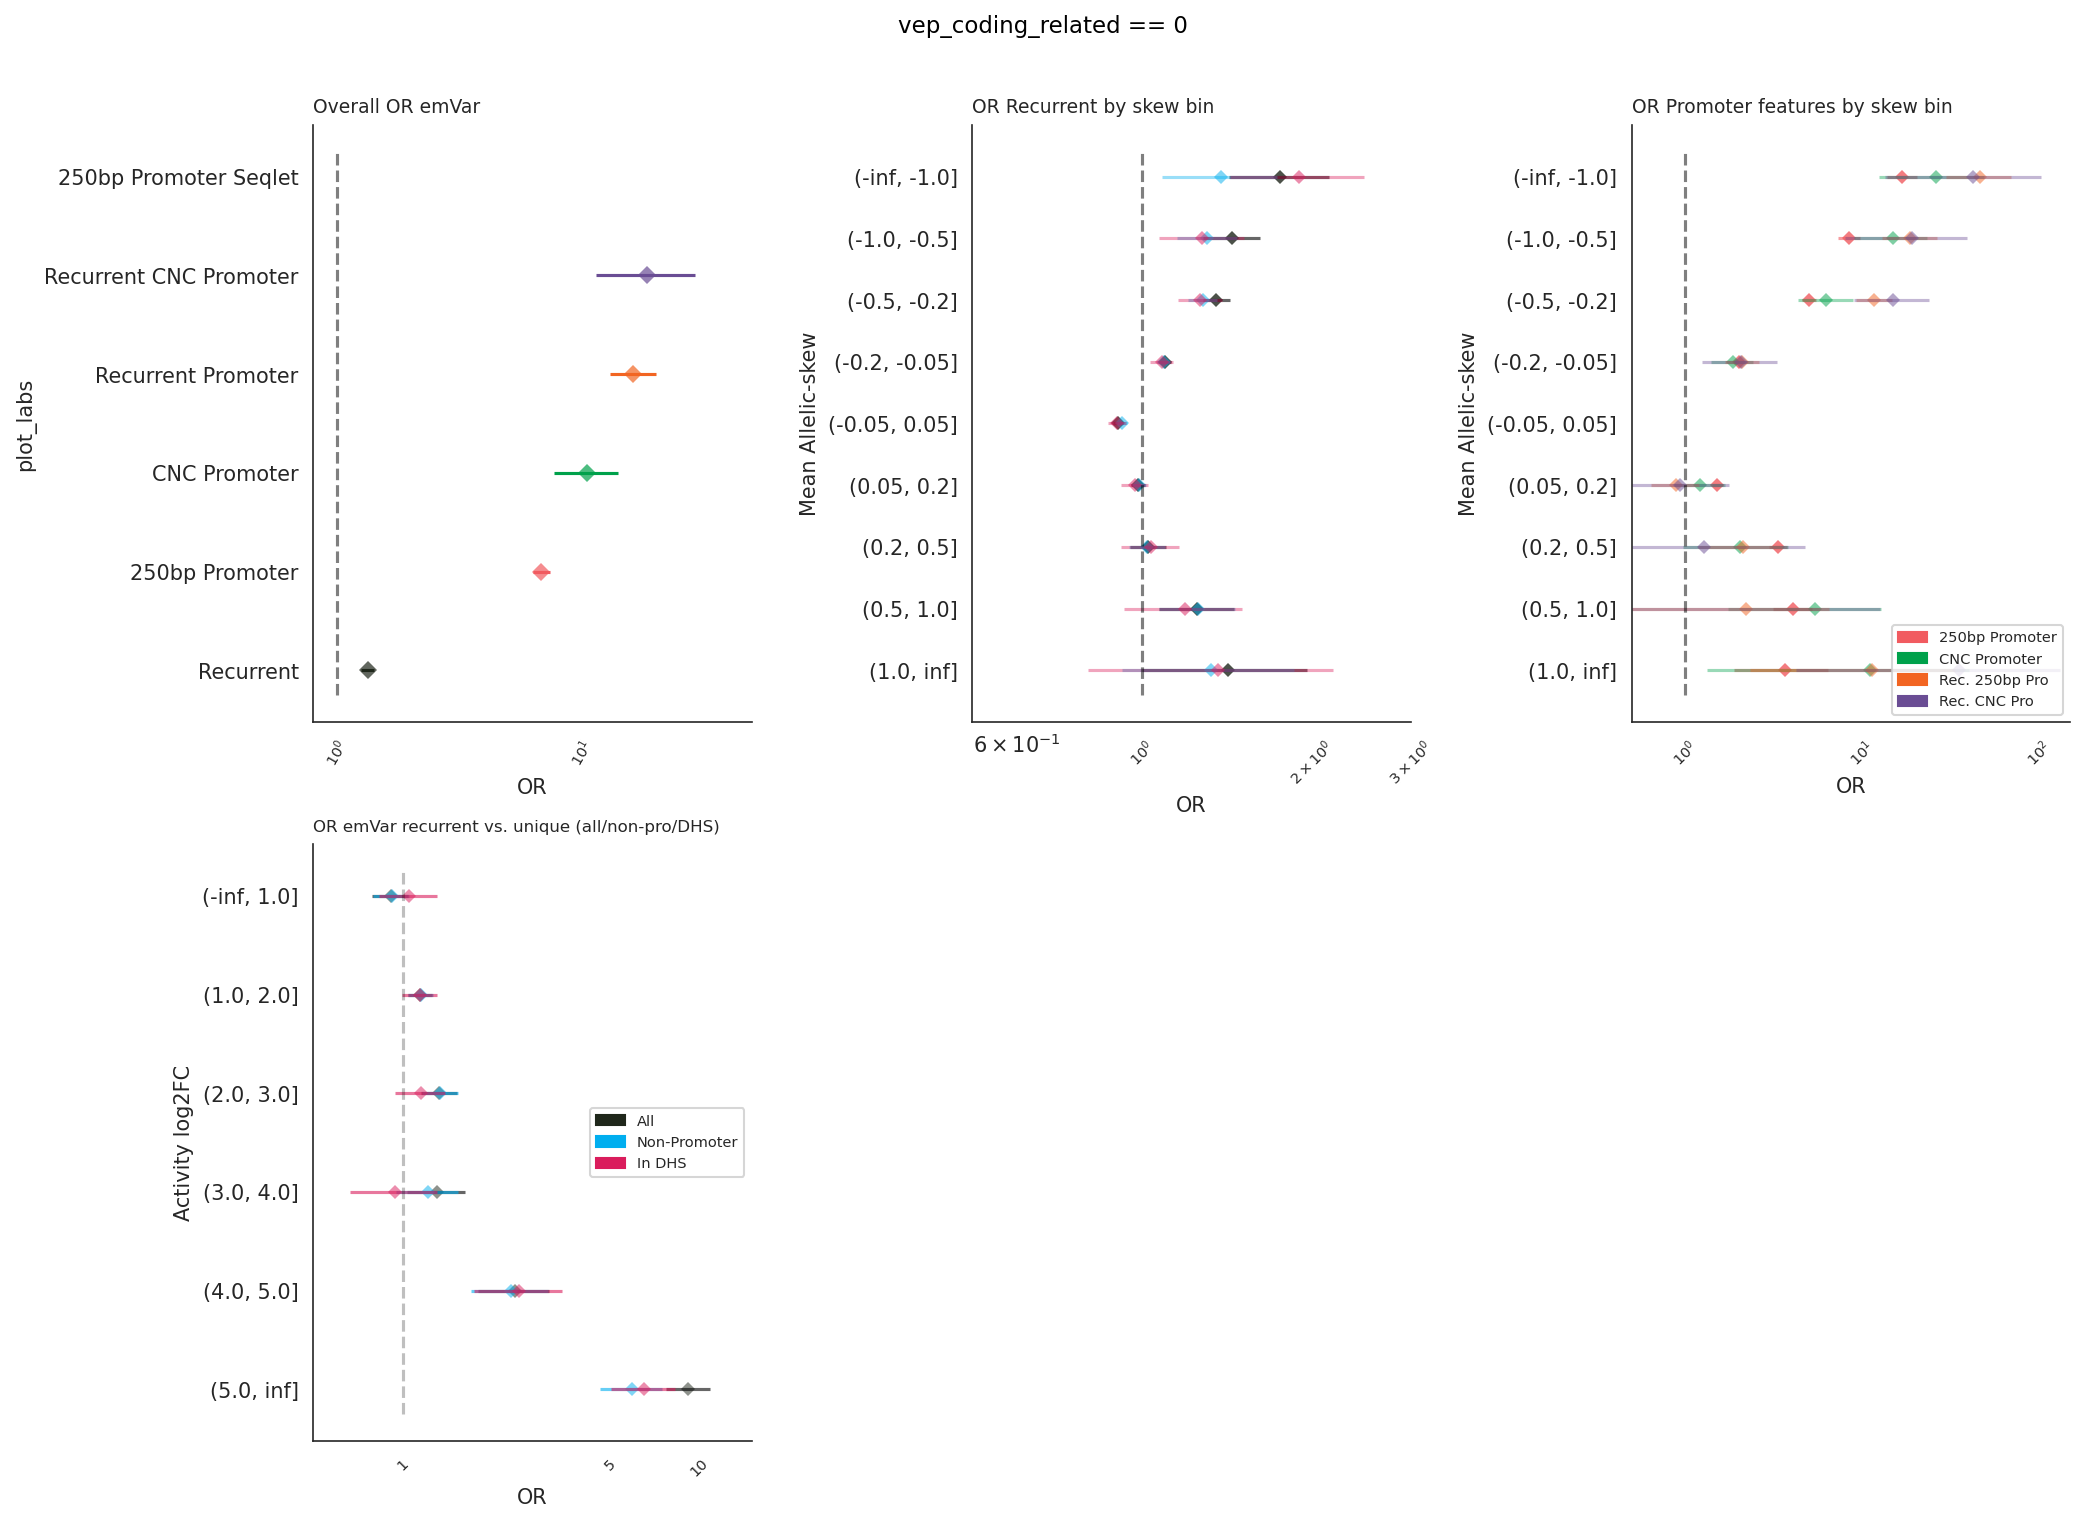

In [27]:
# --- Plot: vep_coding_related == 0 ---
feature_palette = {
    'Recurrent': '#1F271B',
    '250bp Promoter': '#F15B60',
    '250bp Promoter Seqlet': 'dodgerblue',
    'CNC Promoter': '#00A14B',
    'Recurrent Promoter': '#F26522',
    'Recurrent CNC Promoter': '#6A4D94',
}
black_patch = mpatches.Patch(color='#1F271B', label='All')
green_patch = mpatches.Patch(color='#00AEEF', label='Non-Promoter')
blue_patch  = mpatches.Patch(color='#DA1C5C', label='In DHS')

f = plt.figure(dpi=150, figsize=(14, 10))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(2, 3)

# overall OR
with sns.axes_style('white'):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    _sorted = cat_odds_nonCoding.sort_values('OddsR', ascending=False)
    sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',
                  palette=feature_palette, linestyle='none', marker='D',
                  markersize=6, alpha=.7, linewidth=0)
    for _, row in _sorted.iterrows():
        plt.hlines(xmin=row['lowerCI'], xmax=row['upperCI'], y=row['plot_labs'],
                   color=feature_palette.get(row['plot_labs'], 'grey'))
    ymin, ymax = ax0.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('Overall OR emVar', loc='left', size=9)
    plt.xlabel('OR')
    plt.xticks([1, 5, 10, 20, 30], rotation=60, size=7)
    plt.xlim(.8, 50)

# skew bin - recurrent
with sns.axes_style('white'):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    sns.pointplot(data=rec_skew_nonCoding, x='OddsR', y='label',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in rec_skew_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_skew_noPro_nonCoding, x='OddsR', y='label',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.4)
    sns.pointplot(data=rec_skew_noPro_dhs_nonCoding, x='OddsR', y='label',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_dhs_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.4)
    ymin, ymax = ax1.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Recurrent by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xlim(.5, 3)
    plt.xticks([1, 2, 3], rotation=45, size=7)
    plt.xlabel('OR')

# skew bin - promoter features
with sns.axes_style('white'):
    ax2 = f.add_subplot(gs[0, 2])
    ax2.set_xscale('log')
    sns.pointplot(data=pro_skew_nonCoding, x='OddsR', y='label',
                  color='#F15B60', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in pro_skew_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F15B60', alpha=.6)
    sns.pointplot(data=cnc_skew_nonCoding, x='OddsR', y='label',
                  color='#00A14B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in cnc_skew_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00A14B', alpha=.4)
    sns.pointplot(data=rec250_skew_nonCoding, x='OddsR', y='label',
                  color='#F26522', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec250_skew_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F26522', alpha=.4)
    sns.pointplot(data=recCNC_skew_nonCoding, x='OddsR', y='label',
                  color='#6A4D94', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in recCNC_skew_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#6A4D94', alpha=.4)
    ymin, ymax = ax2.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Promoter features by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xticks([1, 5, 10, 25, 50, 100], rotation=45, size=7)
    plt.xlim(.5, 150)
    plt.xlabel('OR')
    pro_patches = [
        mpatches.Patch(color='#F15B60', label='250bp Promoter'),
        mpatches.Patch(color='#00A14B', label='CNC Promoter'),
        mpatches.Patch(color='#F26522', label='Rec. 250bp Pro'),
        mpatches.Patch(color='#6A4D94', label='Rec. CNC Pro'),
    ]
    plt.legend(handles=pro_patches, fontsize=7, loc='lower right')

# activity bin - all/non-promoter/dhs
with sns.axes_style('white'):
    ax3 = f.add_subplot(gs[1, 0])
    ax3.set_xscale('log')
    sns.pointplot(data=rec_emvar_act_nonCoding, x='oddsR', y='Bin',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_nonCoding, x='oddsR', y='Bin',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_dhs_nonCoding, x='oddsR', y='Bin',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_dhs_nonCoding.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.6)
    ymin, ymax = ax3.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    plt.title('OR emVar recurrent vs. unique (all/non-pro/DHS)', loc='left', size=8)
    plt.xlabel('OR')
    plt.xlim(.8, 15)
    plt.xticks([0.5, 1, 5, 10], ['', '1', '5', '10'], rotation=45, size=7)
    plt.ylabel('Activity log2FC')
    plt.legend(handles=[black_patch, green_patch, blue_patch], fontsize=7, loc='center right')

sns.despine()
plt.suptitle('vep_coding_related == 0', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# --- Recurrent OR by skew bin: vep_coding_related == 0 ---
print('--- OR recurrent by skew bin (all): vep_coding_related == 0 ---')
display(rec_skew_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (non-promoter): vep_coding_related == 0 ---')
display(rec_skew_noPro_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (in DHS): vep_coding_related == 0 ---')
display(rec_skew_noPro_dhs_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Promoter features OR by skew bin: vep_coding_related == 0 ---
print('--- OR 250bp promoter by skew bin: vep_coding_related == 0 ---')
display(pro_skew_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR CNC promoter by skew bin: vep_coding_related == 0 ---')
display(cnc_skew_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent 250bp promoter by skew bin: vep_coding_related == 0 ---')
display(rec250_skew_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent CNC promoter by skew bin: vep_coding_related == 0 ---')
display(recCNC_skew_nonCoding[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Activity bin tables: vep_coding_related == 0 ---
print('--- Activity bin OR table (all): vep_coding_related == 0 ---')
display(rec_emvar_act_nonCoding[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter): vep_coding_related == 0 ---')
display(rec_emvar_act_noPro_nonCoding[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (dhs): vep_coding_related == 0 ---')
display(rec_emvar_act_noPro_dhs_nonCoding[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])

--- OR recurrent by skew bin (all): vep_coding_related == 0 ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.759633,1.427152,2.148179,2.764562e-07,101,2507
1,"(-1.0, -0.5]",1.444763,1.283461,1.621152,2.808666e-09,302,9073
2,"(-0.5, -0.2]",1.355579,1.280477,1.434063,3.202412e-24,1288,41359
3,"(-0.2, -0.05]",1.098072,1.069624,1.127145,3.654458e-12,6710,265825
4,"(-0.05, 0.05]",0.907111,0.889497,0.925107,3.032759e-22,33784,1489778
5,"(0.05, 0.2]",0.985190,0.957209,1.013835,3.092010e-01,5397,234438
6,"(0.2, 0.5]",1.024333,0.951005,1.101927,5.101207e-01,751,31467
7,"(0.5, 1.0]",1.253319,1.070848,1.458524,4.508135e-03,173,5958
8,"(1.0, inf]",1.419988,0.999376,1.961592,4.007968e-02,38,1159


--- OR recurrent by skew bin (non-promoter): vep_coding_related == 0 ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.383582,1.085924,1.739215,7.816761e-03,76,2394
1,"(-1.0, -0.5]",1.306356,1.151551,1.476568,3.942849e-05,266,8866
2,"(-0.5, -0.2]",1.281306,1.207834,1.358200,8.135082e-16,1197,40819
3,"(-0.2, -0.05]",1.091797,1.063293,1.120931,9.297307e-11,6598,264483
4,"(-0.05, 0.05]",0.920446,0.902423,0.938864,2.767001e-16,33642,1487398
5,"(0.05, 0.2]",0.987634,0.959459,1.016481,4.010056e-01,5349,233481
6,"(0.2, 0.5]",1.020118,0.946381,1.098188,5.952746e-01,736,31178
7,"(0.5, 1.0]",1.254524,1.070356,1.461847,4.754990e-03,170,5890
8,"(1.0, inf]",1.327871,0.920016,1.858331,1.146355e-01,35,1147


--- OR recurrent by skew bin (in DHS): vep_coding_related == 0 ---


...

,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",0.910412,0.790857,1.043187,1.841118e-01,213,9794,42369,1842865
1,"(1.0, 2.0]",1.146932,1.042525,1.259160,4.490416e-03,458,16744,4098,142098
2,"(2.0, 3.0]",1.327058,1.154350,1.518808,7.130159e-05,219,6919,989,30137
3,"(3.0, 4.0]",1.304226,1.032069,1.627465,2.110342e-02,81,2602,361,10241
4,"(4.0, 5.0]",2.388788,1.795793,3.121357,1.581101e-08,57,1000,236,4344
5,"(5.0, inf]",9.163284,7.718309,10.827746,1.750885e-94,171,784,491,3335


--- Activity bin OR table (non-promoter): vep_coding_related == 0 ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",0.918016,0.797459,1.051905,2.300564e-01,213,9783,42319,1841551
1,"(1.0, 2.0]",1.148872,1.043847,1.261800,4.282975e-03,454,16689,4060,141201
2,"(2.0, 3.0]",1.339921,1.164760,1.534489,5.087393e-05,217,6839,966,29395
3,"(3.0, 4.0]",1.214642,0.947078,1.535626,1.148324e-01,72,2501,324,9505
4,"(4.0, 5.0]",2.323661,1.705765,3.099548,3.081579e-07,49,890,168,3664
5,"(5.0, inf]",5.929696,4.638997,7.494537,1.025406e-33,81,577,232,2271


--- Activity bin OR table (dhs): vep_coding_related == 0 ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.046746,0.831932,1.301124,6.503771e-01,84,3194,8653,370693
1,"(1.0, 2.0]",1.141717,0.991369,1.308988,5.904312e-02,216,7545,1836,62762
2,"(2.0, 3.0]",1.150063,0.940022,1.394022,1.573431e-01,108,3741,546,16363
3,"(3.0, 4.0]",0.944733,0.662301,1.308827,8.077494e-01,37,1558,195,5929
4,"(4.0, 5.0]",2.475366,1.733824,3.438737,1.354453e-06,38,612,128,2615
5,"(5.0, inf]",6.500124,5.037213,8.291424,2.288322e-34,77,474,209,1870


## Analysis: non-coding + synonymous

In [29]:
# --- Overall odds-ratios: non-coding + synonymous ---
recurrent_OR_nonCodingSyn, _ = oddsR_calculator(nonCodingSyn, 'recurrent', 'emvar_any')
twoFifty_OR_nonCodingSyn, _ = oddsR_calculator(nonCodingSyn, '250bp_pro', 'emvar_any')
twoFiftySeqlet_OR_nonCodingSyn, _ = oddsR_calculator(nonCodingSyn, '250_pro_seqlet', 'emvar_any')
cnc_OR_nonCodingSyn, _ = oddsR_calculator(nonCodingSyn, 'cnc_pro', 'emvar_any')
recurrent250_OR_nonCodingSyn, _ = oddsR_calculator(nonCodingSyn, 'recurrent_250bp_pro', 'emvar_any')
recurrentCNC_OR_nonCodingSyn, _ = oddsR_calculator(nonCodingSyn, 'recurrent_cnc_pro', 'emvar_any')

cat_odds_nonCodingSyn = pd.concat([
    recurrent_OR_nonCodingSyn,
    twoFifty_OR_nonCodingSyn,
    twoFiftySeqlet_OR_nonCodingSyn,
    cnc_OR_nonCodingSyn,
    recurrent250_OR_nonCodingSyn,
    recurrentCNC_OR_nonCodingSyn,
])
cat_odds_nonCodingSyn['plot_labs'] = [
    'Recurrent', '250bp Promoter', '250bp Promoter Seqlet',
    'CNC Promoter', 'Recurrent Promoter', 'Recurrent CNC Promoter'
]
display(cat_odds_nonCodingSyn[['plot_labs','OddsR','lowerCI','upperCI','p_val','n_pos_emvar','n_pos_total']].reset_index(drop=True))

,plot_labs,OddsR,lowerCI,upperCI,p_val,n_pos_emvar,n_pos_total
0,Recurrent,1.336959,1.265646,1.411360,6.513069e-24,1392,54307
1,250bp Promoter,6.612525,6.091263,7.169385,1.263515e-293,677,5908
2,250bp Promoter Seqlet,98.372179,75.731668,128.527965,5.363574e-226,173,262
3,CNC Promoter,10.203924,7.492114,13.679005,5.136338e-34,55,327
4,Recurrent Promoter,15.773110,12.652003,19.538588,2.256201e-85,113,475
5,Recurrent CNC Promoter,17.917507,11.098993,28.129890,7.224303e-23,27,103


In [30]:
# --- OR by skew bin: non-coding + synonymous ---
_bins = [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')]

rec_skew_nonCodingSyn = oddsR_feature_by_skew_bin_all(nonCodingSyn, _bins, 'recurrent', 'Recurrent')
rec_skew_nonCodingSyn['label'] = [str(i) for i in rec_skew_nonCodingSyn['Bin']]

rec_skew_noPro_nonCodingSyn = oddsR_feature_by_skew_bin_all(
    nonCodingSyn[nonCodingSyn['250bp_pro'] == 0], _bins, 'recurrent', 'Recurrent: Non-Promoter')
rec_skew_noPro_nonCodingSyn['label'] = [str(i) for i in rec_skew_noPro_nonCodingSyn['Bin']]

rec_skew_noPro_dhs_nonCodingSyn = oddsR_feature_by_skew_bin_all(
    nonCodingSyn[(nonCodingSyn['250bp_pro'] == 0) & (nonCodingSyn['dhs'] == 1)], _bins, 'recurrent', 'Recurrent: In DHS')
rec_skew_noPro_dhs_nonCodingSyn['label'] = [str(i) for i in rec_skew_noPro_dhs_nonCodingSyn['Bin']]

pro_skew_nonCodingSyn = oddsR_feature_by_skew_bin_all(nonCodingSyn, _bins, '250bp_pro', '250bp Promoter')
pro_skew_nonCodingSyn['label'] = [str(i) for i in pro_skew_nonCodingSyn['Bin']]

cnc_skew_nonCodingSyn = oddsR_feature_by_skew_bin_all(nonCodingSyn, _bins, 'cnc_pro', 'CNC Promoter')
cnc_skew_nonCodingSyn['label'] = [str(i) for i in cnc_skew_nonCodingSyn['Bin']]

rec250_skew_nonCodingSyn = oddsR_feature_by_skew_bin_all(nonCodingSyn, _bins, 'recurrent_250bp_pro', 'Recurrent Promoter')
rec250_skew_nonCodingSyn['label'] = [str(i) for i in rec250_skew_nonCodingSyn['Bin']]

recCNC_skew_nonCodingSyn = oddsR_feature_by_skew_bin_all(nonCodingSyn, _bins, 'recurrent_cnc_pro', 'Recurrent CNC Promoter')
recCNC_skew_nonCodingSyn['label'] = [str(i) for i in recCNC_skew_nonCodingSyn['Bin']]

In [31]:
# --- Activity bin analysis: non-coding + synonymous ---
_act_nonCodingSyn = reformat_df4act_bin(nonCodingSyn)

rec_emvar_act_nonCodingSyn = oddsR_emvar_by_act_bin_max(_act_nonCodingSyn)
rec_emvar_act_noPro_nonCodingSyn = oddsR_emvar_by_act_bin_max(_act_nonCodingSyn[_act_nonCodingSyn['250bp_pro'] == 0])
rec_emvar_act_noPro_dhs_nonCodingSyn = oddsR_emvar_by_act_bin_max(
    _act_nonCodingSyn[(_act_nonCodingSyn['250bp_pro'] == 0) & (_act_nonCodingSyn['dhs'] == 1)])
rec_emvar_act_pro_nonCodingSyn = oddsR_emvar_by_act_bin_max(_act_nonCodingSyn[_act_nonCodingSyn['250bp_pro'] == 1])

2190594it [00:01, 1809732.83it/s]


/tmp/ipykernel_3808401/519260296.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',


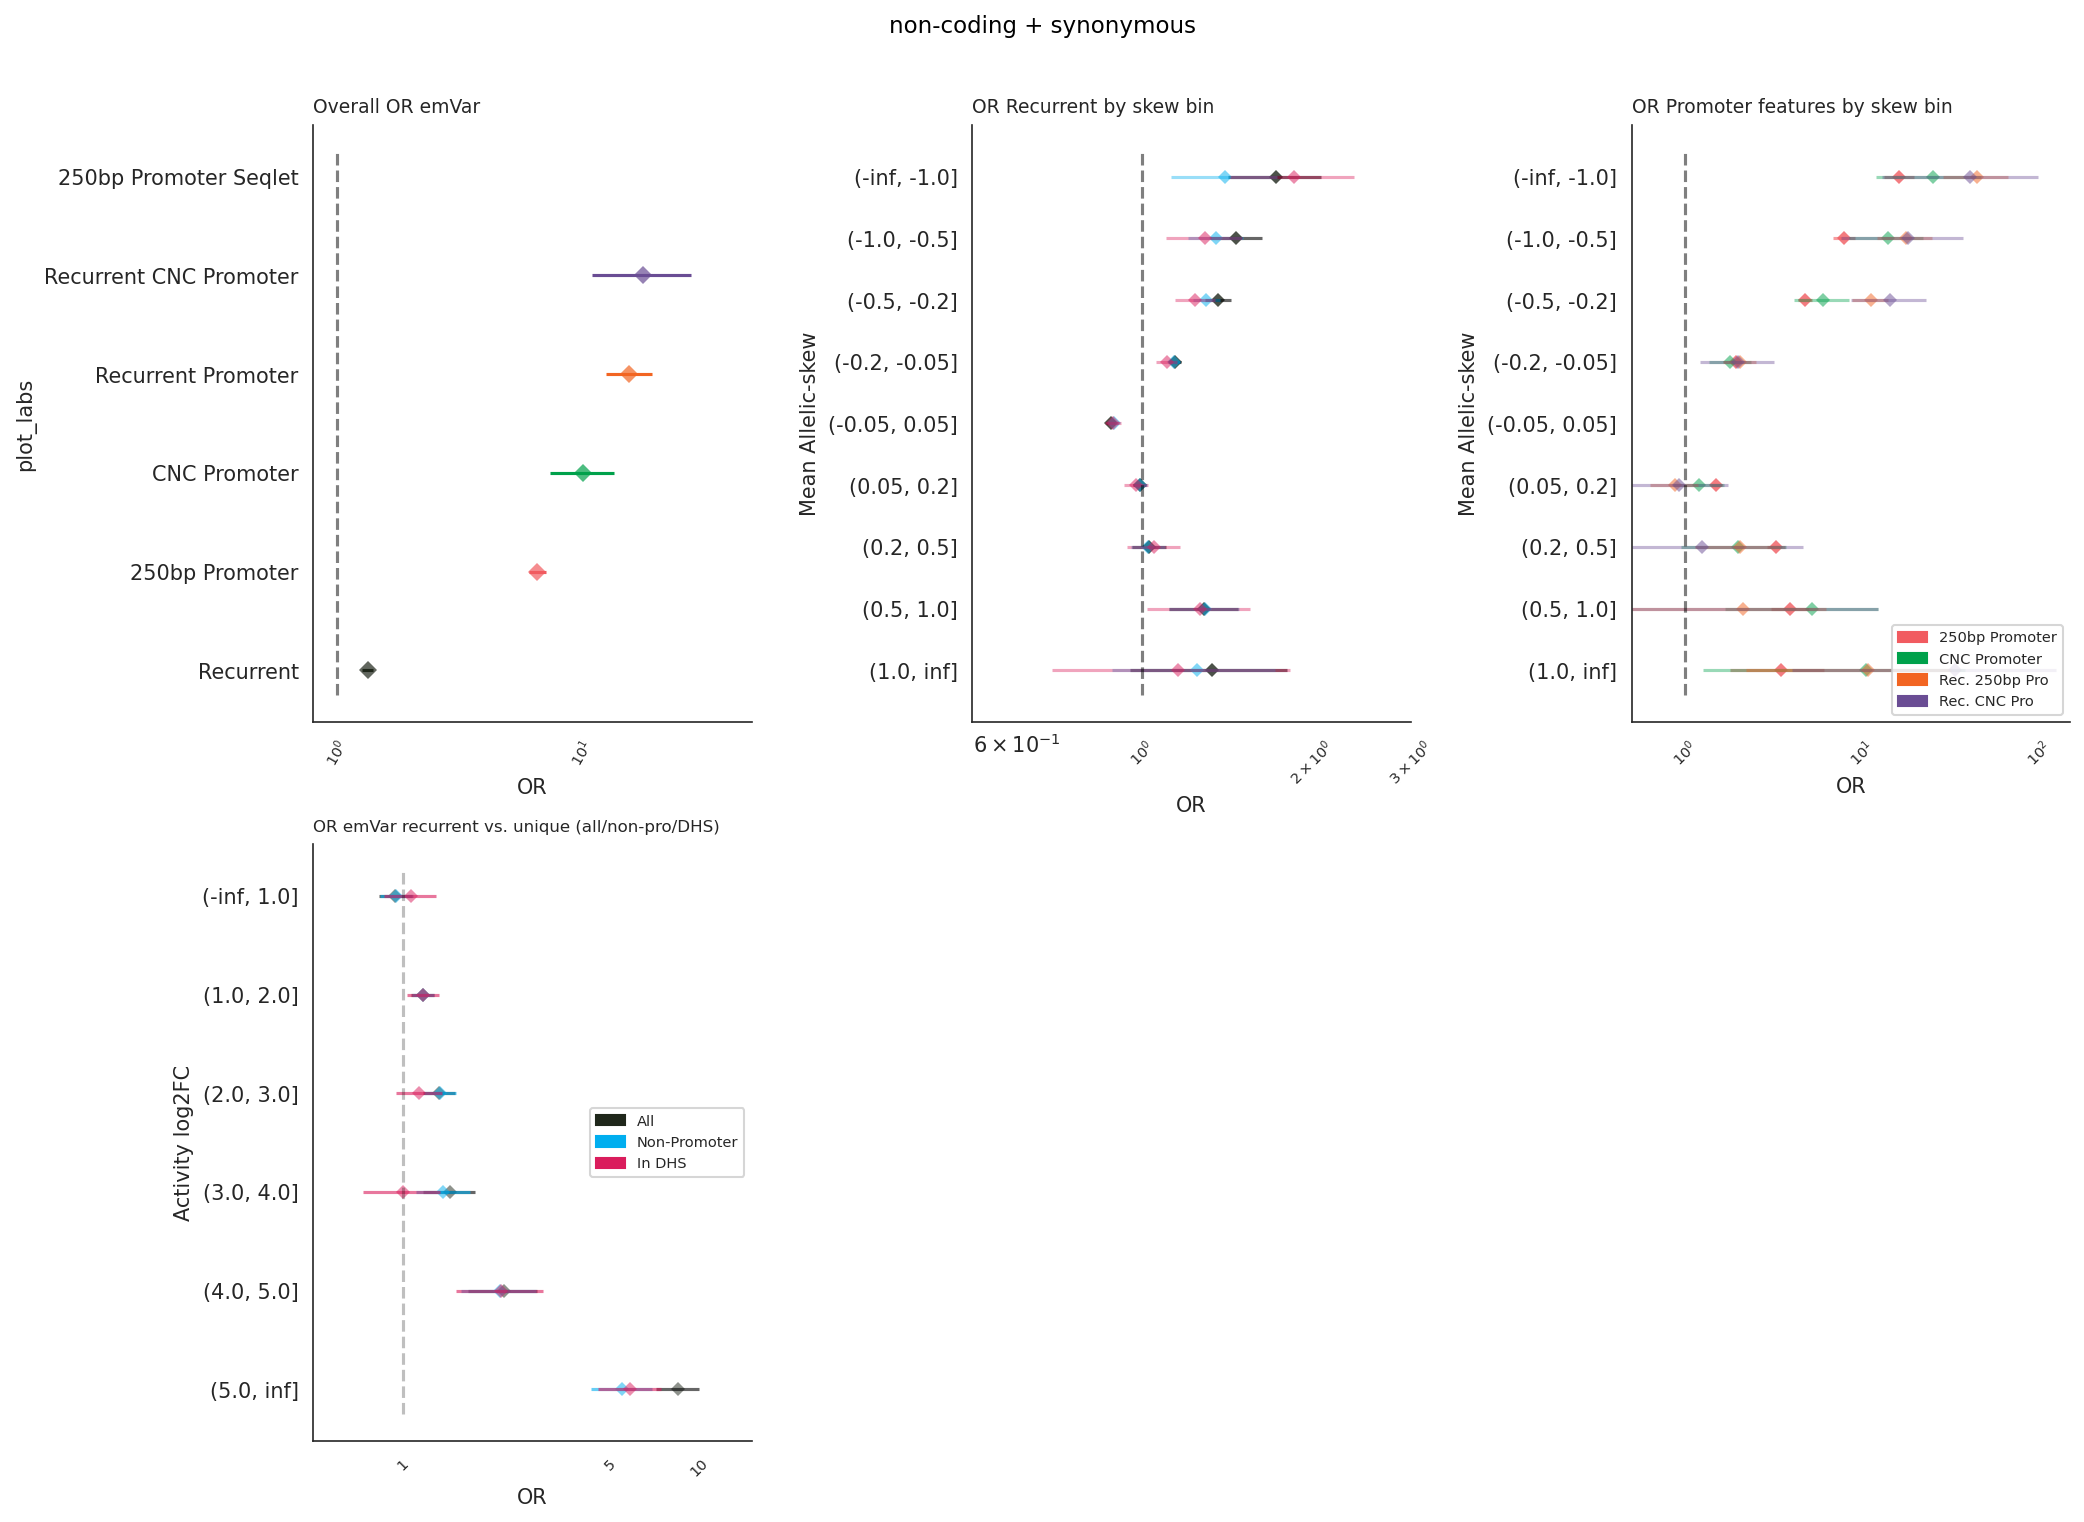

In [32]:
# --- Plot: non-coding + synonymous ---
feature_palette = {
    'Recurrent': '#1F271B',
    '250bp Promoter': '#F15B60',
    '250bp Promoter Seqlet': 'dodgerblue',
    'CNC Promoter': '#00A14B',
    'Recurrent Promoter': '#F26522',
    'Recurrent CNC Promoter': '#6A4D94',
}
black_patch = mpatches.Patch(color='#1F271B', label='All')
green_patch = mpatches.Patch(color='#00AEEF', label='Non-Promoter')
blue_patch  = mpatches.Patch(color='#DA1C5C', label='In DHS')

f = plt.figure(dpi=150, figsize=(14, 10))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(2, 3)

# overall OR
with sns.axes_style('white'):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    _sorted = cat_odds_nonCodingSyn.sort_values('OddsR', ascending=False)
    sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',
                  palette=feature_palette, linestyle='none', marker='D',
                  markersize=6, alpha=.7, linewidth=0)
    for _, row in _sorted.iterrows():
        plt.hlines(xmin=row['lowerCI'], xmax=row['upperCI'], y=row['plot_labs'],
                   color=feature_palette.get(row['plot_labs'], 'grey'))
    ymin, ymax = ax0.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('Overall OR emVar', loc='left', size=9)
    plt.xlabel('OR')
    plt.xticks([1, 5, 10, 20, 30], rotation=60, size=7)
    plt.xlim(.8, 50)

# skew bin - recurrent
with sns.axes_style('white'):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    sns.pointplot(data=rec_skew_nonCodingSyn, x='OddsR', y='label',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in rec_skew_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_skew_noPro_nonCodingSyn, x='OddsR', y='label',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.4)
    sns.pointplot(data=rec_skew_noPro_dhs_nonCodingSyn, x='OddsR', y='label',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_dhs_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.4)
    ymin, ymax = ax1.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Recurrent by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xlim(.5, 3)
    plt.xticks([1, 2, 3], rotation=45, size=7)
    plt.xlabel('OR')

# skew bin - promoter features
with sns.axes_style('white'):
    ax2 = f.add_subplot(gs[0, 2])
    ax2.set_xscale('log')
    sns.pointplot(data=pro_skew_nonCodingSyn, x='OddsR', y='label',
                  color='#F15B60', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in pro_skew_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F15B60', alpha=.6)
    sns.pointplot(data=cnc_skew_nonCodingSyn, x='OddsR', y='label',
                  color='#00A14B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in cnc_skew_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00A14B', alpha=.4)
    sns.pointplot(data=rec250_skew_nonCodingSyn, x='OddsR', y='label',
                  color='#F26522', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec250_skew_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F26522', alpha=.4)
    sns.pointplot(data=recCNC_skew_nonCodingSyn, x='OddsR', y='label',
                  color='#6A4D94', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in recCNC_skew_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#6A4D94', alpha=.4)
    ymin, ymax = ax2.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Promoter features by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xticks([1, 5, 10, 25, 50, 100], rotation=45, size=7)
    plt.xlim(.5, 150)
    plt.xlabel('OR')
    pro_patches = [
        mpatches.Patch(color='#F15B60', label='250bp Promoter'),
        mpatches.Patch(color='#00A14B', label='CNC Promoter'),
        mpatches.Patch(color='#F26522', label='Rec. 250bp Pro'),
        mpatches.Patch(color='#6A4D94', label='Rec. CNC Pro'),
    ]
    plt.legend(handles=pro_patches, fontsize=7, loc='lower right')

# activity bin - all/non-promoter/dhs
with sns.axes_style('white'):
    ax3 = f.add_subplot(gs[1, 0])
    ax3.set_xscale('log')
    sns.pointplot(data=rec_emvar_act_nonCodingSyn, x='oddsR', y='Bin',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_nonCodingSyn, x='oddsR', y='Bin',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_dhs_nonCodingSyn, x='oddsR', y='Bin',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_dhs_nonCodingSyn.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.6)
    ymin, ymax = ax3.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    plt.title('OR emVar recurrent vs. unique (all/non-pro/DHS)', loc='left', size=8)
    plt.xlabel('OR')
    plt.xlim(.8, 15)
    plt.xticks([0.5, 1, 5, 10], ['', '1', '5', '10'], rotation=45, size=7)
    plt.ylabel('Activity log2FC')
    plt.legend(handles=[black_patch, green_patch, blue_patch], fontsize=7, loc='center right')

sns.despine()
plt.suptitle('non-coding + synonymous', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# --- Recurrent OR by skew bin: non-coding + synonymous ---
print('--- OR recurrent by skew bin (all): non-coding + synonymous ---')
display(rec_skew_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (non-promoter): non-coding + synonymous ---')
display(rec_skew_noPro_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (in DHS): non-coding + synonymous ---')
display(rec_skew_noPro_dhs_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Promoter features OR by skew bin: non-coding + synonymous ---
print('--- OR 250bp promoter by skew bin: non-coding + synonymous ---')
display(pro_skew_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR CNC promoter by skew bin: non-coding + synonymous ---')
display(cnc_skew_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent 250bp promoter by skew bin: non-coding + synonymous ---')
display(rec250_skew_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent CNC promoter by skew bin: non-coding + synonymous ---')
display(recCNC_skew_nonCodingSyn[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Activity bin tables: non-coding + synonymous ---
print('--- Activity bin OR table (all): non-coding + synonymous ---')
display(rec_emvar_act_nonCodingSyn[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter): non-coding + synonymous ---')
display(rec_emvar_act_noPro_nonCodingSyn[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter, dhs): non-coding + synonymous ---')
display(rec_emvar_act_noPro_dhs_nonCodingSyn[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])

--- OR recurrent by skew bin (all): non-coding + synonymous ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.726197,1.419228,2.081512,1.028987e-07,115,2738
1,"(-1.0, -0.5]",1.467984,1.317869,1.630896,1.187338e-11,363,10111
2,"(-0.5, -0.2]",1.363504,1.293540,1.436383,5.799771e-29,1510,45399
3,"(-0.2, -0.05]",1.143846,1.116498,1.171751,4.214231e-27,7988,287875
4,"(-0.05, 0.05]",0.880590,0.864587,0.896916,1.421352e-41,37079,1553092
5,"(0.05, 0.2]",0.990529,0.964080,1.017567,4.940111e-01,6134,249473
6,"(0.2, 0.5]",1.029500,0.960862,1.101850,3.996936e-01,870,34128
7,"(0.5, 1.0]",1.290025,1.117087,1.482668,4.998916e-04,206,6493
8,"(1.0, inf]",1.329429,0.953170,1.807884,7.230988e-02,42,1285


--- OR recurrent by skew bin (non-promoter): non-coding + synonymous ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.406007,1.126288,1.735545,2.422315e-03,90,2625
1,"(-1.0, -0.5]",1.353696,1.208307,1.512123,2.723564e-07,327,9904
2,"(-0.5, -0.2]",1.300955,1.232226,1.372629,1.799552e-20,1419,44859
3,"(-0.2, -0.05]",1.139149,1.111738,1.167122,2.919553e-25,7876,286533
4,"(-0.05, 0.05]",0.891216,0.874904,0.907859,5.556144e-34,36937,1550712
5,"(0.05, 0.2]",0.992906,0.966290,1.020118,6.110625e-01,6086,248516
6,"(0.2, 0.5]",1.026488,0.957476,1.099264,4.473736e-01,855,33839
7,"(0.5, 1.0]",1.292558,1.118066,1.487084,5.195973e-04,203,6425
8,"(1.0, inf]",1.251197,0.885245,1.720542,1.738112e-01,39,1273


--- OR recurrent by skew bin (in DHS): non-coding + synonymous ---


...

,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",0.945446,0.830397,1.072219,3.989644e-01,250,10399,46926,1924047
1,"(1.0, 2.0]",1.168540,1.070781,1.273005,4.703935e-04,546,18407,5038,159216
2,"(2.0, 3.0]",1.328637,1.169303,1.504059,1.686882e-05,260,7707,1191,33803
3,"(3.0, 4.0]",1.439841,1.172137,1.751677,5.603155e-04,104,2843,412,11151
4,"(4.0, 5.0]",2.188753,1.654308,2.846359,1.272311e-07,59,1061,246,4606
5,"(5.0, inf]",8.467138,7.141136,9.992624,1.591404e-90,173,806,494,3464


--- Activity bin OR table (non-promoter): non-coding + synonymous ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",0.952402,0.836503,1.080112,4.708475e-01,250,10388,46876,1922733
1,"(1.0, 2.0]",1.170758,1.072466,1.275818,4.425676e-04,542,18352,5000,158319
2,"(2.0, 3.0]",1.340628,1.179248,1.518371,8.767382e-06,258,7627,1168,33061
3,"(3.0, 4.0]",1.372073,1.106056,1.684047,3.553789e-03,95,2742,375,10415
4,"(4.0, 5.0]",2.123834,1.569664,2.816273,1.944225e-06,51,951,178,3926
5,"(5.0, inf]",5.491772,4.310745,6.919758,2.708153e-32,83,599,235,2400


--- Activity bin OR table (non-promoter, dhs): non-coding + synonymous ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.065570,0.865757,1.298607,5.328715e-01,102,3472,10363,402697
1,"(1.0, 2.0]",1.170484,1.032304,1.322501,1.336139e-02,272,8449,2336,72628
2,"(2.0, 3.0]",1.138561,0.949983,1.354435,1.450326e-01,133,4240,673,18791
3,"(3.0, 4.0]",1.003026,0.736312,1.336600,9.415010e-01,48,1735,223,6562
4,"(4.0, 5.0]",2.145536,1.511109,2.966119,2.902644e-05,39,660,135,2813
5,"(5.0, inf]",5.837007,4.540369,7.419676,3.131335e-32,79,493,212,1974


## Analysis: non-coding + (synonymous & dELS)

In [34]:
# --- Overall odds-ratios: non-coding + (synonymous & dELS) ---
recurrent_OR_nonCodingSynDELS, _ = oddsR_calculator(nonCodingSynDELS, 'recurrent', 'emvar_any')
twoFifty_OR_nonCodingSynDELS, _ = oddsR_calculator(nonCodingSynDELS, '250bp_pro', 'emvar_any')
twoFiftySeqlet_OR_nonCodingSynDELS, _ = oddsR_calculator(nonCodingSynDELS, '250_pro_seqlet', 'emvar_any')
cnc_OR_nonCodingSynDELS, _ = oddsR_calculator(nonCodingSynDELS, 'cnc_pro', 'emvar_any')
recurrent250_OR_nonCodingSynDELS, _ = oddsR_calculator(nonCodingSynDELS, 'recurrent_250bp_pro', 'emvar_any')
recurrentCNC_OR_nonCodingSynDELS, _ = oddsR_calculator(nonCodingSynDELS, 'recurrent_cnc_pro', 'emvar_any')

cat_odds_nonCodingSynDELS = pd.concat([
    recurrent_OR_nonCodingSynDELS,
    twoFifty_OR_nonCodingSynDELS,
    twoFiftySeqlet_OR_nonCodingSynDELS,
    cnc_OR_nonCodingSynDELS,
    recurrent250_OR_nonCodingSynDELS,
    recurrentCNC_OR_nonCodingSynDELS,
])
cat_odds_nonCodingSynDELS['plot_labs'] = [
    'Recurrent', '250bp Promoter', '250bp Promoter Seqlet',
    'CNC Promoter', 'Recurrent Promoter', 'Recurrent CNC Promoter'
]
display(cat_odds_nonCodingSynDELS[['plot_labs','OddsR','lowerCI','upperCI','p_val','n_pos_emvar','n_pos_total']].reset_index(drop=True))

,plot_labs,OddsR,lowerCI,upperCI,p_val,n_pos_emvar,n_pos_total
0,Recurrent,1.347002,1.271858,1.425552,4.998363e-23,1269,49952
1,250bp Promoter,6.729769,6.199064,7.296744,7.850306e-298,677,5908
2,250bp Promoter Seqlet,98.316662,75.622197,128.554729,1.299621e-222,170,259
3,CNC Promoter,10.377291,7.619339,13.911546,2.261062e-34,55,327
4,Recurrent Promoter,16.042275,12.867746,19.872259,3.916855e-86,113,475
5,Recurrent CNC Promoter,18.221335,11.287129,28.607068,4.741474e-23,27,103


In [35]:
# --- OR by skew bin: non-coding + (synonymous & dELS) ---
_bins = [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')]

rec_skew_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(nonCodingSynDELS, _bins, 'recurrent', 'Recurrent')
rec_skew_nonCodingSynDELS['label'] = [str(i) for i in rec_skew_nonCodingSynDELS['Bin']]

rec_skew_noPro_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(
    nonCodingSynDELS[nonCodingSynDELS['250bp_pro'] == 0], _bins, 'recurrent', 'Recurrent: Non-Promoter')
rec_skew_noPro_nonCodingSynDELS['label'] = [str(i) for i in rec_skew_noPro_nonCodingSynDELS['Bin']]

rec_skew_noPro_dhs_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(
    nonCodingSynDELS[(nonCodingSynDELS['250bp_pro'] == 0) & (nonCodingSynDELS['dhs'] == 1)], _bins, 'recurrent', 'Recurrent: In DHS')
rec_skew_noPro_dhs_nonCodingSynDELS['label'] = [str(i) for i in rec_skew_noPro_dhs_nonCodingSynDELS['Bin']]

pro_skew_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(nonCodingSynDELS, _bins, '250bp_pro', '250bp Promoter')
pro_skew_nonCodingSynDELS['label'] = [str(i) for i in pro_skew_nonCodingSynDELS['Bin']]

cnc_skew_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(nonCodingSynDELS, _bins, 'cnc_pro', 'CNC Promoter')
cnc_skew_nonCodingSynDELS['label'] = [str(i) for i in cnc_skew_nonCodingSynDELS['Bin']]

rec250_skew_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(nonCodingSynDELS, _bins, 'recurrent_250bp_pro', 'Recurrent Promoter')
rec250_skew_nonCodingSynDELS['label'] = [str(i) for i in rec250_skew_nonCodingSynDELS['Bin']]

recCNC_skew_nonCodingSynDELS = oddsR_feature_by_skew_bin_all(nonCodingSynDELS, _bins, 'recurrent_cnc_pro', 'Recurrent CNC Promoter')
recCNC_skew_nonCodingSynDELS['label'] = [str(i) for i in recCNC_skew_nonCodingSynDELS['Bin']]

In [36]:
# --- Activity bin analysis: non-coding + (synonymous & dELS) ---
_act_nonCodingSynDELS = reformat_df4act_bin(nonCodingSynDELS)

rec_emvar_act_nonCodingSynDELS = oddsR_emvar_by_act_bin_max(_act_nonCodingSynDELS)
rec_emvar_act_noPro_nonCodingSynDELS = oddsR_emvar_by_act_bin_max(_act_nonCodingSynDELS[_act_nonCodingSynDELS['250bp_pro'] == 0])
rec_emvar_act_noPro_dhs_nonCodingSynDELS = oddsR_emvar_by_act_bin_max(
    _act_nonCodingSynDELS[(_act_nonCodingSynDELS['250bp_pro'] == 0) & (_act_nonCodingSynDELS['dhs'] == 1)])
rec_emvar_act_pro_nonCodingSynDELS = oddsR_emvar_by_act_bin_max(_act_nonCodingSynDELS[_act_nonCodingSynDELS['250bp_pro'] == 1])

2111299it [00:00, 2111743.57it/s]


/tmp/ipykernel_3808401/2071080055.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',


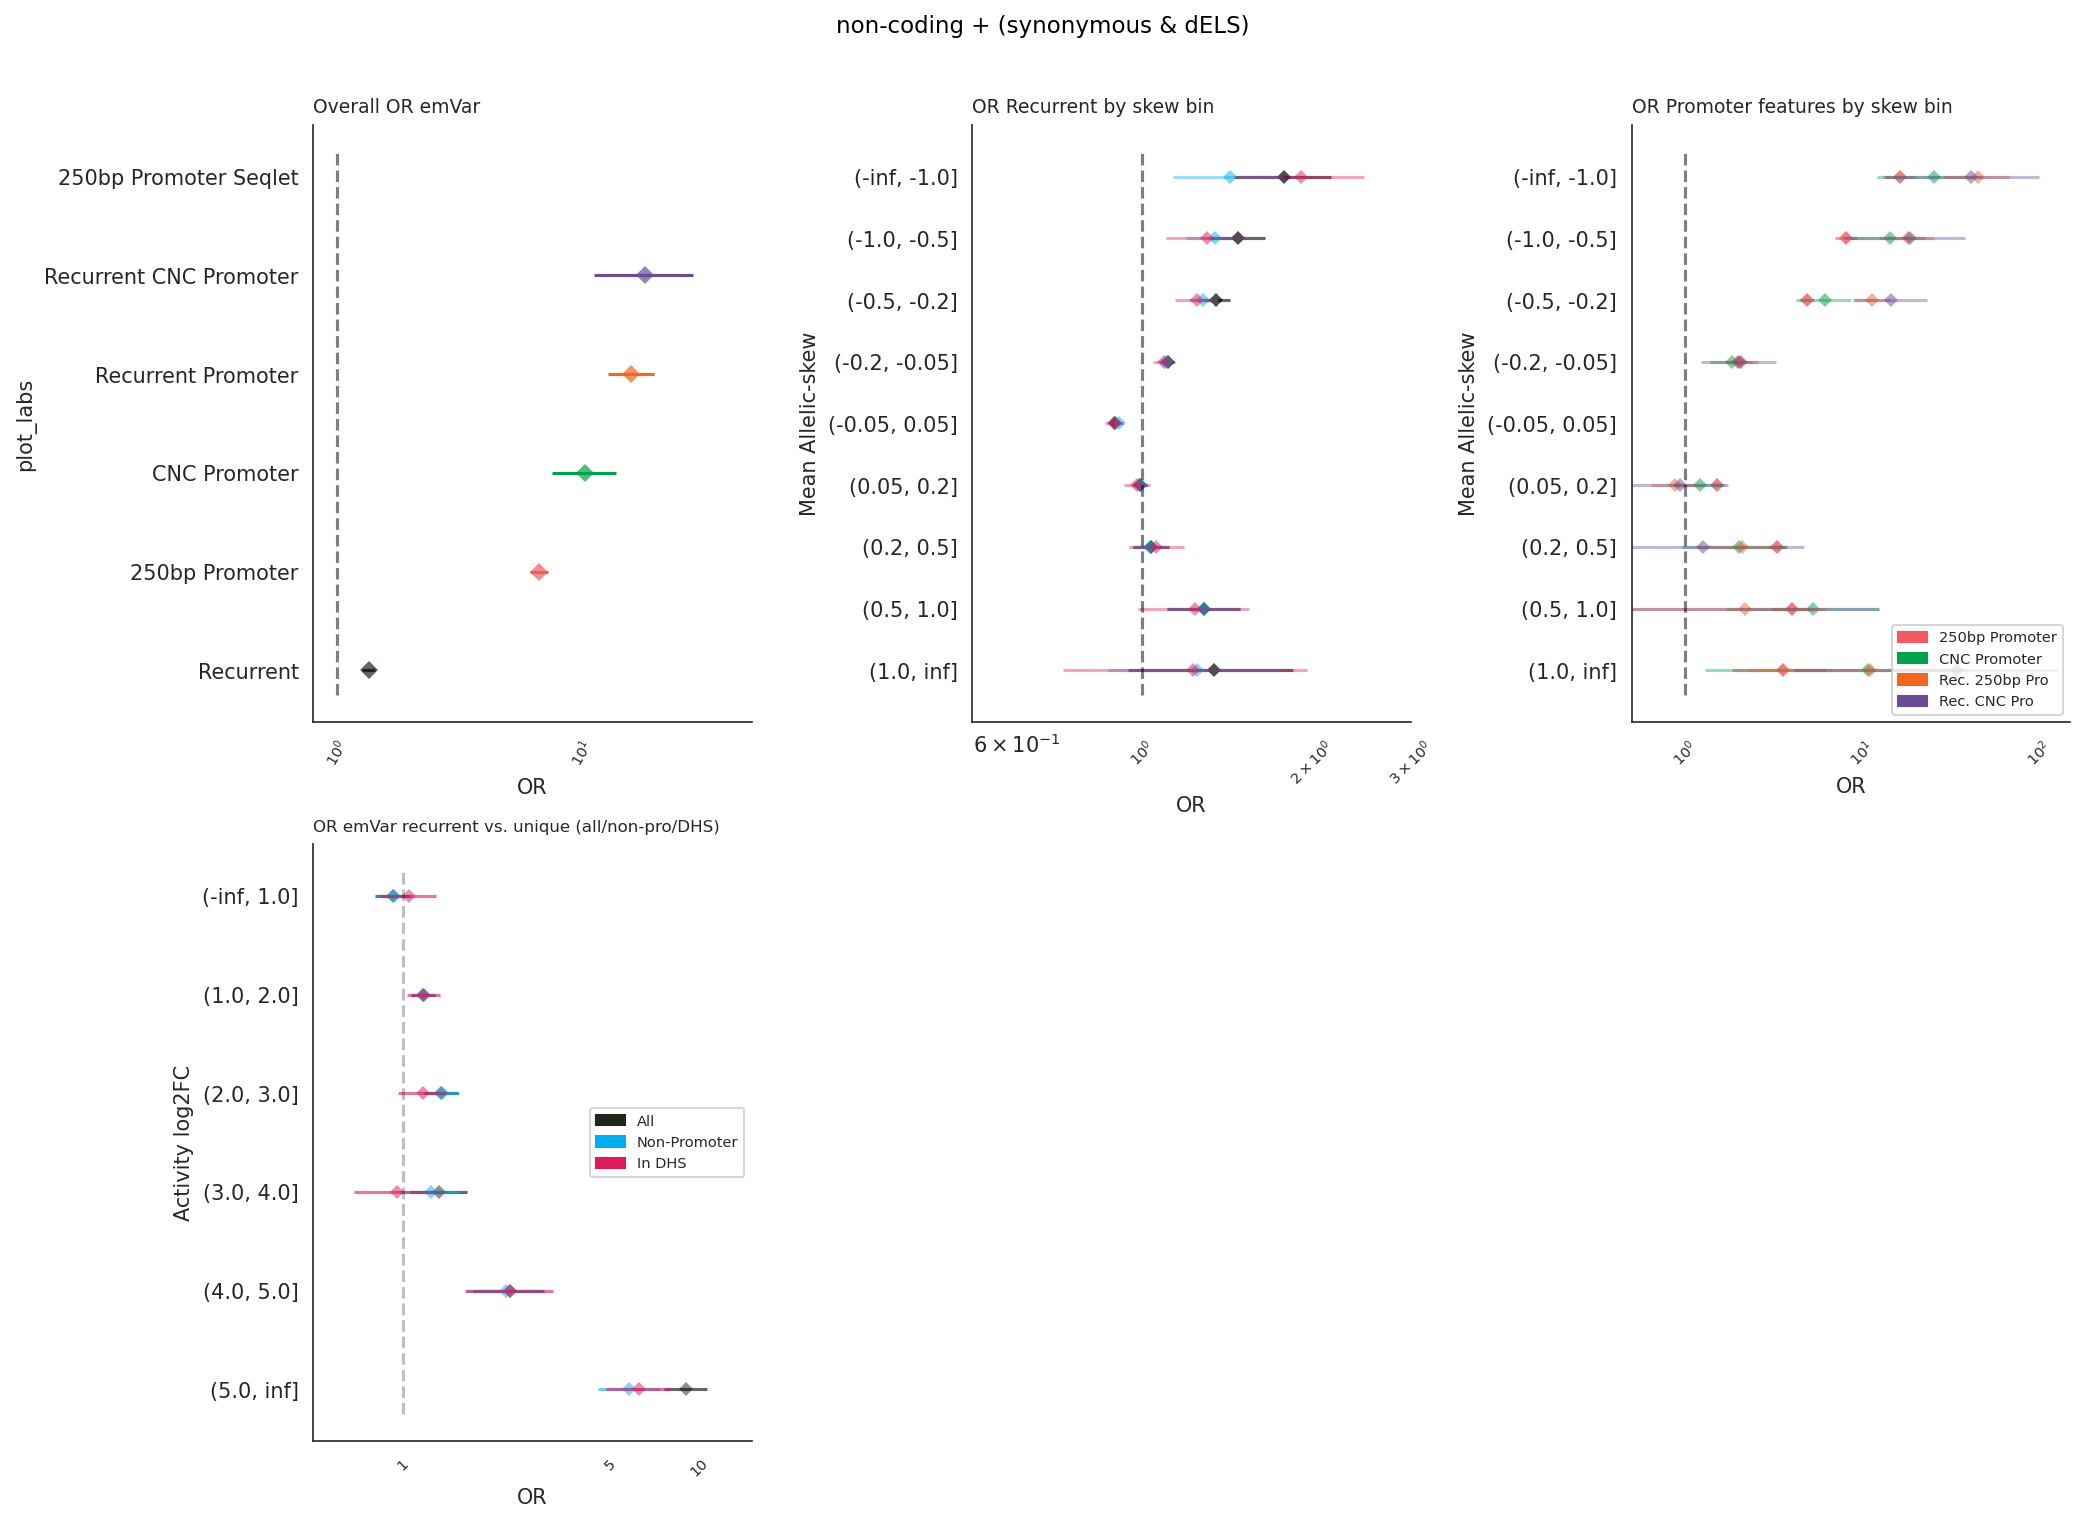

In [37]:
# --- Plot: non-coding + (synonymous & dELS) ---
feature_palette = {
    'Recurrent': '#1F271B',
    '250bp Promoter': '#F15B60',
    '250bp Promoter Seqlet': 'dodgerblue',
    'CNC Promoter': '#00A14B',
    'Recurrent Promoter': '#F26522',
    'Recurrent CNC Promoter': '#6A4D94',
}
black_patch = mpatches.Patch(color='#1F271B', label='All')
green_patch = mpatches.Patch(color='#00AEEF', label='Non-Promoter')
blue_patch  = mpatches.Patch(color='#DA1C5C', label='In DHS')

f = plt.figure(dpi=150, figsize=(14, 10))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(2, 3)

# overall OR
with sns.axes_style('white'):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    _sorted = cat_odds_nonCodingSynDELS.sort_values('OddsR', ascending=False)
    sns.pointplot(data=_sorted, x='OddsR', y='plot_labs',
                  palette=feature_palette, linestyle='none', marker='D',
                  markersize=6, alpha=.7, linewidth=0)
    for _, row in _sorted.iterrows():
        plt.hlines(xmin=row['lowerCI'], xmax=row['upperCI'], y=row['plot_labs'],
                   color=feature_palette.get(row['plot_labs'], 'grey'))
    ymin, ymax = ax0.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('Overall OR emVar', loc='left', size=9)
    plt.xlabel('OR')
    plt.xticks([1, 5, 10, 20, 30], rotation=60, size=7)
    plt.xlim(.8, 50)

# skew bin - recurrent
with sns.axes_style('white'):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    sns.pointplot(data=rec_skew_nonCodingSynDELS, x='OddsR', y='label',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in rec_skew_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_skew_noPro_nonCodingSynDELS, x='OddsR', y='label',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.4)
    sns.pointplot(data=rec_skew_noPro_dhs_nonCodingSynDELS, x='OddsR', y='label',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_skew_noPro_dhs_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.4)
    ymin, ymax = ax1.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Recurrent by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xlim(.5, 3)
    plt.xticks([1, 2, 3], rotation=45, size=7)
    plt.xlabel('OR')

# skew bin - promoter features
with sns.axes_style('white'):
    ax2 = f.add_subplot(gs[0, 2])
    ax2.set_xscale('log')
    sns.pointplot(data=pro_skew_nonCodingSynDELS, x='OddsR', y='label',
                  color='#F15B60', linestyle='none', marker='D', markersize=5, alpha=.8, linewidth=0)
    for _, r in pro_skew_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F15B60', alpha=.6)
    sns.pointplot(data=cnc_skew_nonCodingSynDELS, x='OddsR', y='label',
                  color='#00A14B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in cnc_skew_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00A14B', alpha=.4)
    sns.pointplot(data=rec250_skew_nonCodingSynDELS, x='OddsR', y='label',
                  color='#F26522', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec250_skew_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#F26522', alpha=.4)
    sns.pointplot(data=recCNC_skew_nonCodingSynDELS, x='OddsR', y='label',
                  color='#6A4D94', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in recCNC_skew_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#6A4D94', alpha=.4)
    ymin, ymax = ax2.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('OR Promoter features by skew bin', loc='left', size=9)
    plt.ylabel('Mean Allelic-skew')
    plt.xticks([1, 5, 10, 25, 50, 100], rotation=45, size=7)
    plt.xlim(.5, 150)
    plt.xlabel('OR')
    pro_patches = [
        mpatches.Patch(color='#F15B60', label='250bp Promoter'),
        mpatches.Patch(color='#00A14B', label='CNC Promoter'),
        mpatches.Patch(color='#F26522', label='Rec. 250bp Pro'),
        mpatches.Patch(color='#6A4D94', label='Rec. CNC Pro'),
    ]
    plt.legend(handles=pro_patches, fontsize=7, loc='lower right')

# activity bin - all/non-promoter/dhs
with sns.axes_style('white'):
    ax3 = f.add_subplot(gs[1, 0])
    ax3.set_xscale('log')
    sns.pointplot(data=rec_emvar_act_nonCodingSynDELS, x='oddsR', y='Bin',
                  color='#1F271B', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='k', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_nonCodingSynDELS, x='oddsR', y='Bin',
                  color='#00AEEF', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#00AEEF', alpha=.6)
    sns.pointplot(data=rec_emvar_act_noPro_dhs_nonCodingSynDELS, x='oddsR', y='Bin',
                  color='#DA1C5C', linestyle='none', marker='D', markersize=5, alpha=.5, linewidth=0)
    for _, r in rec_emvar_act_noPro_dhs_nonCodingSynDELS.iterrows():
        plt.hlines(xmin=r['lowerCI'], xmax=r['upperCI'], y=r['label'], color='#DA1C5C', alpha=.6)
    ymin, ymax = ax3.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    plt.title('OR emVar recurrent vs. unique (all/non-pro/DHS)', loc='left', size=8)
    plt.xlabel('OR')
    plt.xlim(.8, 15)
    plt.xticks([0.5, 1, 5, 10], ['', '1', '5', '10'], rotation=45, size=7)
    plt.ylabel('Activity log2FC')
    plt.legend(handles=[black_patch, green_patch, blue_patch], fontsize=7, loc='center right')

sns.despine()
plt.suptitle('non-coding + (synonymous & dELS)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [38]:
# --- Recurrent OR by skew bin: non-coding + (synonymous & dELS) ---
print('--- OR recurrent by skew bin (all): non-coding + (synonymous & dELS) ---')
display(rec_skew_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (non-promoter): non-coding + (synonymous & dELS) ---')
display(rec_skew_noPro_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent by skew bin (in DHS): non-coding + (synonymous & dELS) ---')
display(rec_skew_noPro_dhs_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Promoter features OR by skew bin: non-coding + (synonymous & dELS) ---
print('--- OR 250bp promoter by skew bin: non-coding + (synonymous & dELS) ---')
display(pro_skew_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR CNC promoter by skew bin: non-coding + (synonymous & dELS) ---')
display(cnc_skew_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent 250bp promoter by skew bin: non-coding + (synonymous & dELS) ---')
display(rec250_skew_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])
print('--- OR recurrent CNC promoter by skew bin: non-coding + (synonymous & dELS) ---')
display(recCNC_skew_nonCodingSynDELS[['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']])

# --- Activity bin tables: non-coding + (synonymous & dELS) ---
print('--- Activity bin OR table (all): non-coding + (synonymous & dELS) ---')
display(rec_emvar_act_nonCodingSynDELS[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter): non-coding + (synonymous & dELS) ---')
display(rec_emvar_act_noPro_nonCodingSynDELS[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])
print('--- Activity bin OR table (non-promoter, dhs): non-coding + (synonymous & dELS) ---')
display(rec_emvar_act_noPro_dhs_nonCodingSynDELS[['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']])

--- OR recurrent by skew bin (all): non-coding + (synonymous & dELS) ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.785126,1.458170,2.165325,4.953925e-08,108,2607
1,"(-1.0, -0.5]",1.477260,1.318689,1.650061,5.932834e-11,328,9510
2,"(-0.5, -0.2]",1.354615,1.281251,1.431207,3.495385e-25,1350,42769
3,"(-0.2, -0.05]",1.110282,1.082143,1.139027,2.066657e-15,7040,272415
4,"(-0.05, 0.05]",0.896184,0.879102,0.913627,1.186183e-28,34504,1505596
5,"(0.05, 0.2]",0.991345,0.963690,1.019645,5.481187e-01,5605,238695
6,"(0.2, 0.5]",1.037823,0.965450,1.114297,3.019204e-01,793,32343
7,"(0.5, 1.0]",1.286543,1.105525,1.489295,1.043556e-03,186,6157
8,"(1.0, inf]",1.341688,0.944478,1.852946,8.687587e-02,38,1207


--- OR recurrent by skew bin (non-promoter): non-coding + (synonymous & dELS) ---


,Bin,OddsR,lowerCI,upperCI,p_val,n_feature_in_bin,n_bin
0,"(-inf, -1.0]",1.431206,1.135554,1.781833,2.265328e-03,83,2494
1,"(-1.0, -0.5]",1.348573,1.195693,1.515970,1.510503e-06,292,9303
2,"(-0.5, -0.2]",1.284143,1.212281,1.359271,9.019325e-17,1259,42229
3,"(-0.2, -0.05]",1.104481,1.076284,1.133289,7.106049e-14,6928,271073
4,"(-0.05, 0.05]",0.908603,0.891147,0.926433,5.351121e-22,34362,1503216
5,"(0.05, 0.2]",0.993831,0.965988,1.022326,6.715320e-01,5557,237738
6,"(0.2, 0.5]",1.034179,0.961395,1.111125,3.529639e-01,778,32054
7,"(0.5, 1.0]",1.288603,1.105889,1.493440,1.090798e-03,183,6089
8,"(1.0, inf]",1.253932,0.868975,1.754407,1.808090e-01,35,1195


--- OR recurrent by skew bin (in DHS): non-coding + (synonymous & dELS) ---


...

,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",0.928174,0.809419,1.059698,2.817856e-01,225,10000,43386,1863101
1,"(1.0, 2.0]",1.172945,1.069869,1.283465,6.441130e-04,493,17370,4403,148378
2,"(2.0, 3.0]",1.345486,1.176496,1.532408,1.907492e-05,236,7247,1060,31543
3,"(3.0, 4.0]",1.328797,1.060544,1.645530,1.244113e-02,87,2703,375,10549
4,"(4.0, 5.0]",2.294063,1.724905,2.996945,5.805249e-08,57,1026,237,4421
5,"(5.0, inf]",8.993796,7.576029,10.626742,2.659836e-93,171,787,491,3355


--- Activity bin OR table (non-promoter): non-coding + (synonymous & dELS) ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",0.935678,0.815959,1.068270,3.423279e-01,225,9989,43336,1861787
1,"(1.0, 2.0]",1.175245,1.071561,1.286447,6.037120e-04,489,17315,4365,147481
2,"(2.0, 3.0]",1.358383,1.187065,1.547964,1.129414e-05,234,7167,1037,30801
3,"(3.0, 4.0]",1.246017,0.981498,1.561148,6.375985e-02,78,2602,338,9813
4,"(4.0, 5.0]",2.224021,1.632977,2.965896,1.024414e-06,49,916,169,3741
5,"(5.0, inf]",5.810957,4.546463,7.343812,3.806853e-33,81,580,232,2291


--- Activity bin OR table (non-promoter, dhs): non-coding + (synonymous & dELS) ---


,Bin,oddsR,lowerCI,upperCI,p_val,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,"(-inf, 1.0]",1.047810,0.840638,1.291547,6.625921e-01,91,3337,9275,383444
1,"(1.0, 2.0]",1.178849,1.032283,1.340932,1.458760e-02,244,7974,2045,67078
2,"(2.0, 3.0]",1.168224,0.965903,1.401334,9.972007e-02,121,3984,599,17438
3,"(3.0, 4.0]",0.960137,0.686038,1.309101,8.764691e-01,41,1640,206,6180
4,"(4.0, 5.0]",2.306203,1.615936,3.202350,6.521885e-06,38,634,129,2683
5,"(5.0, inf]",6.232805,4.830820,7.949051,3.158196e-33,77,477,209,1890


## Cross-filter OR comparison summary

In [39]:
# Collect overall OR tables from all five filter groups for direct comparison
comparison_rows = []
for grp_label, cat_df, var_n in [
    ('No filter',                         cat_odds_noFilt,          'noFilt'),
    ('vep_most_severe != 0',              cat_odds_vepAnn,          'vepAnn'),
    ('vep_coding_related == 0',           cat_odds_nonCoding,       'nonCoding'),
    ('non-coding + synonymous',           cat_odds_nonCodingSyn,    'nonCodingSyn'),
    ('non-coding + (synonymous & dELS)',  cat_odds_nonCodingSynDELS,'nonCodingSynDELS'),
]:
    for _, row in cat_df.iterrows():
        comparison_rows.append({
            'filter_group': grp_label,
            'feature': row['plot_labs'],
            'OddsR': round(row['OddsR'], 3),
            'lowerCI': round(row['lowerCI'], 3),
            'upperCI': round(row['upperCI'], 3),
            'p_val': row['p_val'],
            'n_pos_emvar': row['n_pos_emvar'],
            'n_pos_total': row['n_pos_total'],
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.pivot_table(
    index='feature', columns='filter_group', values='OddsR'
).round(3))

filter_group,No filter,non-coding + (synonymous & dELS),non-coding + synonymous,vep_coding_related == 0,vep_most_severe != 0
feature,,,,,
250bp Promoter,6.078,6.730,6.613,6.873,6.078
250bp Promoter Seqlet,90.202,98.317,98.372,100.362,90.202
CNC Promoter,9.405,10.377,10.204,10.592,9.405
Recurrent,1.290,1.347,1.337,1.335,1.290
Recurrent CNC Promoter,16.516,18.221,17.918,18.598,16.516
Recurrent Promoter,14.534,16.042,15.773,16.375,14.534


In [40]:
# Full comparison table
display(comparison_df)

,filter_group,feature,OddsR,lowerCI,upperCI,p_val,n_pos_emvar,n_pos_total
0,No filter,Recurrent,1.290,1.231,1.351,1.639116e-25,1924,71793
1,No filter,250bp Promoter,6.078,5.600,6.590,1.473301e-273,677,5908
2,No filter,250bp Promoter Seqlet,90.202,69.734,117.333,3.691298e-226,178,270
3,No filter,CNC Promoter,9.405,6.905,12.607,2.667253e-32,55,327
4,No filter,Recurrent Promoter,14.534,11.658,18.002,1.045377e-81,113,475
5,No filter,Recurrent CNC Promoter,16.516,10.231,25.929,5.515636e-22,27,103
6,vep_most_severe != 0,Recurrent,1.290,1.231,1.351,1.639116e-25,1924,71793
7,vep_most_severe != 0,250bp Promoter,6.078,5.600,6.590,1.473301e-273,677,5908
8,vep_most_severe != 0,250bp Promoter Seqlet,90.202,69.734,117.333,3.691298e-226,178,270
9,vep_most_severe != 0,CNC Promoter,9.405,6.905,12.607,2.667253e-32,55,327


## Export tables to Excel

In [ ]:
# --- Export all tables to Excel ---
import openpyxl

skew_cols = ['Bin','OddsR','lowerCI','upperCI','p_val','n_feature_in_bin','n_bin']
act_cols  = ['Bin','oddsR','lowerCI','upperCI','p_val','n_recurrent_emvars','n_unique_emvars','n_recurrent_in_bin','n_unique_in_bin']
or_cols   = ['plot_labs','OddsR','lowerCI','upperCI','p_val','n_pos_emvar','n_pos_total']

sheets = [
    ('summary',              summary_df.reset_index()),
    ('noFilt_overall_OR',    cat_odds_noFilt[or_cols].reset_index(drop=True)),
    ('noFilt_rec_skew_all',  rec_skew_noFilt[skew_cols]),
    ('noFilt_rec_skew_noPro',rec_skew_noPro_noFilt[skew_cols]),
    ('noFilt_rec_skew_dhs',  rec_skew_noPro_dhs_noFilt[skew_cols]),
    ('noFilt_pro_skew',      pro_skew_noFilt[skew_cols]),
    ('noFilt_cnc_skew',      cnc_skew_noFilt[skew_cols]),
    ('noFilt_rec250_skew',   rec250_skew_noFilt[skew_cols]),
    ('noFilt_recCNC_skew',   recCNC_skew_noFilt[skew_cols]),
    ('noFilt_act_all',       rec_emvar_act_noFilt[act_cols]),
    ('noFilt_act_noPro',     rec_emvar_act_noPro_noFilt[act_cols]),
    ('vepAnn_overall_OR',    cat_odds_vepAnn[or_cols].reset_index(drop=True)),
    ('vepAnn_rec_skew_all',  rec_skew_vepAnn[skew_cols]),
    ('vepAnn_rec_skew_noPro',rec_skew_noPro_vepAnn[skew_cols]),
    ('vepAnn_rec_skew_dhs',  rec_skew_noPro_dhs_vepAnn[skew_cols]),
    ('vepAnn_pro_skew',      pro_skew_vepAnn[skew_cols]),
    ('vepAnn_cnc_skew',      cnc_skew_vepAnn[skew_cols]),
    ('vepAnn_rec250_skew',   rec250_skew_vepAnn[skew_cols]),
    ('vepAnn_recCNC_skew',   recCNC_skew_vepAnn[skew_cols]),
    ('vepAnn_act_all',       rec_emvar_act_vepAnn[act_cols]),
    ('vepAnn_act_noPro',     rec_emvar_act_noPro_vepAnn[act_cols]),
    ('ncod_overall_OR',      cat_odds_nonCoding[or_cols].reset_index(drop=True)),
    ('ncod_rec_skew_all',    rec_skew_nonCoding[skew_cols]),
    ('ncod_rec_skew_noPro',  rec_skew_noPro_nonCoding[skew_cols]),
    ('ncod_rec_skew_dhs',    rec_skew_noPro_dhs_nonCoding[skew_cols]),
    ('ncod_pro_skew',        pro_skew_nonCoding[skew_cols]),
    ('ncod_cnc_skew',        cnc_skew_nonCoding[skew_cols]),
    ('ncod_rec250_skew',     rec250_skew_nonCoding[skew_cols]),
    ('ncod_recCNC_skew',     recCNC_skew_nonCoding[skew_cols]),
    ('ncod_act_all',         rec_emvar_act_nonCoding[act_cols]),
    ('ncod_act_noPro',       rec_emvar_act_noPro_nonCoding[act_cols]),
    ('ncodSyn_overall_OR',   cat_odds_nonCodingSyn[or_cols].reset_index(drop=True)),
    ('ncodSyn_rec_skew_all', rec_skew_nonCodingSyn[skew_cols]),
    ('ncodSyn_rec_skew_noPro',rec_skew_noPro_nonCodingSyn[skew_cols]),
    ('ncodSyn_rec_skew_dhs', rec_skew_noPro_dhs_nonCodingSyn[skew_cols]),
    ('ncodSyn_pro_skew',     pro_skew_nonCodingSyn[skew_cols]),
    ('ncodSyn_cnc_skew',     cnc_skew_nonCodingSyn[skew_cols]),
    ('ncodSyn_rec250_skew',  rec250_skew_nonCodingSyn[skew_cols]),
    ('ncodSyn_recCNC_skew',  recCNC_skew_nonCodingSyn[skew_cols]),
    ('ncodSyn_act_all',      rec_emvar_act_nonCodingSyn[act_cols]),
    ('ncodSyn_act_noPro',    rec_emvar_act_noPro_nonCodingSyn[act_cols]),
    ('ncodSynDELS_overall_OR',  cat_odds_nonCodingSynDELS[or_cols].reset_index(drop=True)),
    ('ncodSynDELS_rec_skew_all',rec_skew_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_rec_skew_noPro',rec_skew_noPro_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_rec_skew_dhs',rec_skew_noPro_dhs_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_pro_skew',    pro_skew_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_cnc_skew',    cnc_skew_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_rec250_skew', rec250_skew_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_recCNC_skew', recCNC_skew_nonCodingSynDELS[skew_cols]),
    ('ncodSynDELS_act_all',     rec_emvar_act_nonCodingSynDELS[act_cols]),
    ('ncodSynDELS_act_noPro',   rec_emvar_act_noPro_nonCodingSynDELS[act_cols]),
    ('comparison_pivot',     comparison_df.pivot_table(index='feature', columns='filter_group', values='OddsR').round(3).reset_index()),
    ('comparison_full',      comparison_df),
]

out_path = '../processed_data/cosmic_analysis_v8_tables.xlsx'
with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    for sheet_name, df in sheets:
        df.to_excel(writer, sheet_name=sheet_name, index=False)
print(f'Saved tables to {out_path}')